# Causal Demand Intelligence System
## Análisis Exploratorio: Corporación Favorita

**Autor:** Christian Flores Lozano | **Dataset:** Favorita Grocery Sales, Kaggle 2017


### Resumen

Este documento presenta el análisis exploratorio de 125 millones de registros de ventas de
Corporación Favorita, la cadena de supermercados más grande de Ecuador, correspondientes al
período 2013-2017. El objetivo es diagnosticar las propiedades estadísticas y causales que
determinan la arquitectura del modelo predictivo posterior.

El análisis aplica tres marcos metodológicos: la clasificación MNAR/MAR/MCAR de Little y
Rubin (2002) para el mecanismo de datos faltantes, que condiciona la estrategia de imputación
y previene sesgos en la estimación del efecto promocional; la descomposición STL robusta de
Cleveland et al. (1990) para separar tendencia, estacionalidad y residuo sin que los valores
atípicos de feriados distorsionen la estimación; y los intervalos de confianza bootstrap de
Efron y Tibshirani (1993) para cuantificar la incertidumbre del efecto causal promocional sin
depender de supuestos paramétricos.

| Sección | Contenido |
|---|---|
| 1 | Auditoría de esquema e integridad referencial |
| 2 | Diagnóstico MCAR / MAR / MNAR de valores faltantes |
| 3 | Pipeline de procesamiento con justificación metodológica |
| 4 | Análisis distribucional y concentración Pareto |
| 5 | Estructura temporal: STL, ACF/PACF, heatmap de calendario |
| 6 | Efecto causal de promociones con bootstrap CI |
| 7 | Señales macroeconómicas con corrección de tendencia |
| 8 | Selección cuantitativa de subconjuntos |
| 9 | Hallazgos y marco causal |

---

In [2]:
import warnings
warnings.filterwarnings("ignore")

import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Rutas
ROOT      = Path("D:/Proyectos para Portafolio/Causal Demand Intelligence System")
DB_PATH   = ROOT / "data/raw/favorita.duckdb"
ECU_MACRO_PATH = ROOT / "data/external/ecuador_macro_mensual.csv"
(ROOT / "reports").mkdir(exist_ok=True)

# Paleta colorblind-safe (IBM Design)
PAL = dict(
    ink    = "#212121",
    red    = "#DA1E28",
    blue   = "#0043CE",
    teal   = "#007D79",
    orange = "#FF832B",
    purple = "#6929C4",
    green  = "#198038",
    gray   = "#6F6F6F",
    bg     = "#F4F4F4",
)
SUBSET_PAL = {
    "T44 - GROCERY I" : PAL["blue"],
    "T3 - BEVERAGES"  : PAL["red"],
    "T44 - PRODUCE"   : PAL["green"],
    "T45 - GROCERY I" : PAL["teal"],
    "T49 - BEVERAGES" : PAL["orange"],
}

plt.rcParams.update({
    "figure.dpi"       : 160,
    "figure.facecolor" : "white",
    "axes.facecolor"   : PAL["bg"],
    "axes.edgecolor"   : "#C6C6C6",
    "axes.grid"        : True,
    "grid.color"       : "white",
    "grid.linewidth"   : 1.2,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.labelsize"   : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.titlepad"    : 10,
    "xtick.labelsize"  : 8,
    "ytick.labelsize"  : 8,
    "legend.fontsize"  : 8,
    "legend.framealpha": 0.9,
    "font.family"      : "sans-serif",
    "figure.titlesize" : 14,
    "figure.titleweight": "bold",
})

con = duckdb.connect(str(DB_PATH), read_only=True)
print("Conectado a DuckDB")
print("Tablas:", con.execute("SHOW TABLES").df()["name"].tolist())

Conectado a DuckDB
Tablas: ['holidays_events', 'items', 'oil', 'sales', 'stores', 'transactions']


## 1. Auditoría de Esquema e Integridad Referencial

La auditoría de esquema precede al análisis estadístico y evalúa los tipos de datos, las
cardinalidades y las relaciones entre las seis tablas del sistema: *sales*, *stores*, *items*,
*transactions*, *holidays_events* y *oil*. Esta etapa detecta inconsistencias que, de no
resolverse, propagan errores silenciosos a lo largo del pipeline analítico. Se revisa además
la existencia de claves foráneas huérfanas, registros de ventas que referencian tiendas o
productos inexistentes, y los valores únicos de campos categóricos críticos, en particular
*onpromotion*.

In [3]:
# 1.1 Esquema completo de todas las tablas
schemas = {}
for t in ["sales","stores","items","transactions","holidays_events","oil"]:
    schemas[t] = con.execute(f"DESCRIBE {t}").df()[["column_name","column_type"]]

print(f"{'TABLA':<18}{'COLUMNA':<22}{'TIPO':<12}NOTA")
print("-" * 70)
for tbl, df in schemas.items():
    for _, row in df.iterrows():
        nota = ""
        if tbl == "sales" and row.column_name == "onpromotion":
            nota = "ADVERTENCIA: deberia ser BOOLEAN"
        if tbl == "items" and row.column_name == "perishable":
            nota = "ADVERTENCIA: deberia ser BOOLEAN"
        print(f"{tbl:<18}{row.column_name:<22}{row.column_type:<12}{nota}")
    print()


TABLA             COLUMNA               TIPO        NOTA
----------------------------------------------------------------------
sales             id                    BIGINT      
sales             date                  DATE        
sales             store_nbr             BIGINT      
sales             item_nbr              BIGINT      
sales             unit_sales            DOUBLE      
sales             onpromotion           VARCHAR     ADVERTENCIA: deberia ser BOOLEAN

stores            store_nbr             BIGINT      
stores            city                  VARCHAR     
stores            state                 VARCHAR     
stores            type                  VARCHAR     
stores            cluster               BIGINT      

items             item_nbr              BIGINT      
items             family                VARCHAR     
items             class                 BIGINT      
items             perishable            BIGINT      ADVERTENCIA: deberia ser BOOLEAN

transactio

### Observaciones del esquema

La inspección identifica dos anomalías de tipo que requieren corrección. El campo
*sales.onpromotion* está almacenado como *VARCHAR* en lugar de *BOOLEAN*, con valores
importados como cadenas de texto *'True'*, *'False'* y *NaN*. Esto impide operaciones lógicas
directas y sugiere que la columna fue añadida al dataset en una etapa posterior a la captura
original, un antecedente relevante para el diagnóstico MNAR de la Sección 2.

El campo *items.perishable* está codificado como *BIGINT* con valores 0 y 1 cuando
semánticamente corresponde a un indicador booleano. La corrección mediante conversión de tipo
es directa, pero se documenta para preservar la reproducibilidad del pipeline.

In [4]:
# 1.2 Integridad referencial y valores unicos
item_hue  = con.execute(
    "SELECT COUNT(DISTINCT s.item_nbr) n FROM sales s "
    "LEFT JOIN items i USING(item_nbr) WHERE i.item_nbr IS NULL").df()["n"][0]
store_hue = con.execute(
    "SELECT COUNT(DISTINCT s.store_nbr) n FROM sales s "
    "LEFT JOIN stores st USING(store_nbr) WHERE st.store_nbr IS NULL").df()["n"][0]
promo_vals = con.execute(
    "SELECT onpromotion, COUNT(*) n FROM sales GROUP BY 1 ORDER BY 2 DESC").df()
oil_na_dow = con.execute(
    "SELECT DAYNAME(date) dia, "
    "COUNT(*) FILTER(WHERE dcoilwtico IS NULL) na_n, COUNT(*) total "
    "FROM oil GROUP BY 1 ORDER BY 2 DESC").df()

print(f"item_nbr  huerfanos en sales: {item_hue}  OK")
print(f"store_nbr huerfanos en sales: {store_hue}  OK")
print()
print("Valores unicos en onpromotion:")
print(promo_vals.to_string(index=False))
print()
print("NAs en oil por dia de semana (feriados NYMEX):")
print(oil_na_dow.to_string(index=False))


item_nbr  huerfanos en sales: 0  OK
store_nbr huerfanos en sales: 0  OK

Valores unicos en onpromotion:
onpromotion        n
      False 96028767
        NaN 21657651
       True  7810622

NAs en oil por dia de semana (feriados NYMEX):
      dia  na_n  total
   Monday    23    243
   Friday     9    243
 Thursday     7    244
  Tuesday     2    244
Wednesday     2    244


### Resultados de integridad referencial

El esquema relacional es íntegro: no existen claves foráneas huérfanas, con 0 valores de
*item_nbr* y 0 de *store_nbr* en *sales* sin correspondencia en las tablas de referencia, lo
que descarta una fuente de sesgo por datos incompletos.

La distribución de *onpromotion* muestra 96 millones de registros con valor *False* (76.5%),
21.6 millones con valor *NaN* (17.3%) y 7.8 millones con valor *True* (6.2%). La proporción de
valores faltantes es alta y estructurada, no aleatoria. Los valores faltantes en
*oil.dcoilwtico* se concentran predominantemente los lunes, 23 de 243 lunes del período, lo
que apunta a un patrón vinculado al calendario de operación del mercado NYMEX. Ambos patrones
se formalizan en la Sección 2.

## 2. Diagnóstico de Calidad de Datos: Marco MCAR / MAR / MNAR

La taxonomía de Rubin (1976) y Little y Rubin (2002) clasifica los mecanismos de datos
faltantes en tres categorías, que determinan qué estrategia de tratamiento es válida y cuáles
introducen sesgo sistemático en las estimaciones causales posteriores.

| Mecanismo | Definición | Estrategia correcta |
|---|---|---|
| MCAR | La probabilidad de que un dato falte no depende de ninguna variable, observada ni no observada | Imputación simple, media o mediana, sin introducir sesgo |
| MAR | La probabilidad de que un dato falte depende de variables observadas, pero no del valor faltante mismo | MICE, Expectation-Maximization o imputación condicional |
| MNAR | La probabilidad de que un dato falte depende del propio valor no observado | No imputar. Crear indicador de régimen o modelar el mecanismo explícitamente |

A continuación se clasifica cada variable con datos faltantes en el sistema.

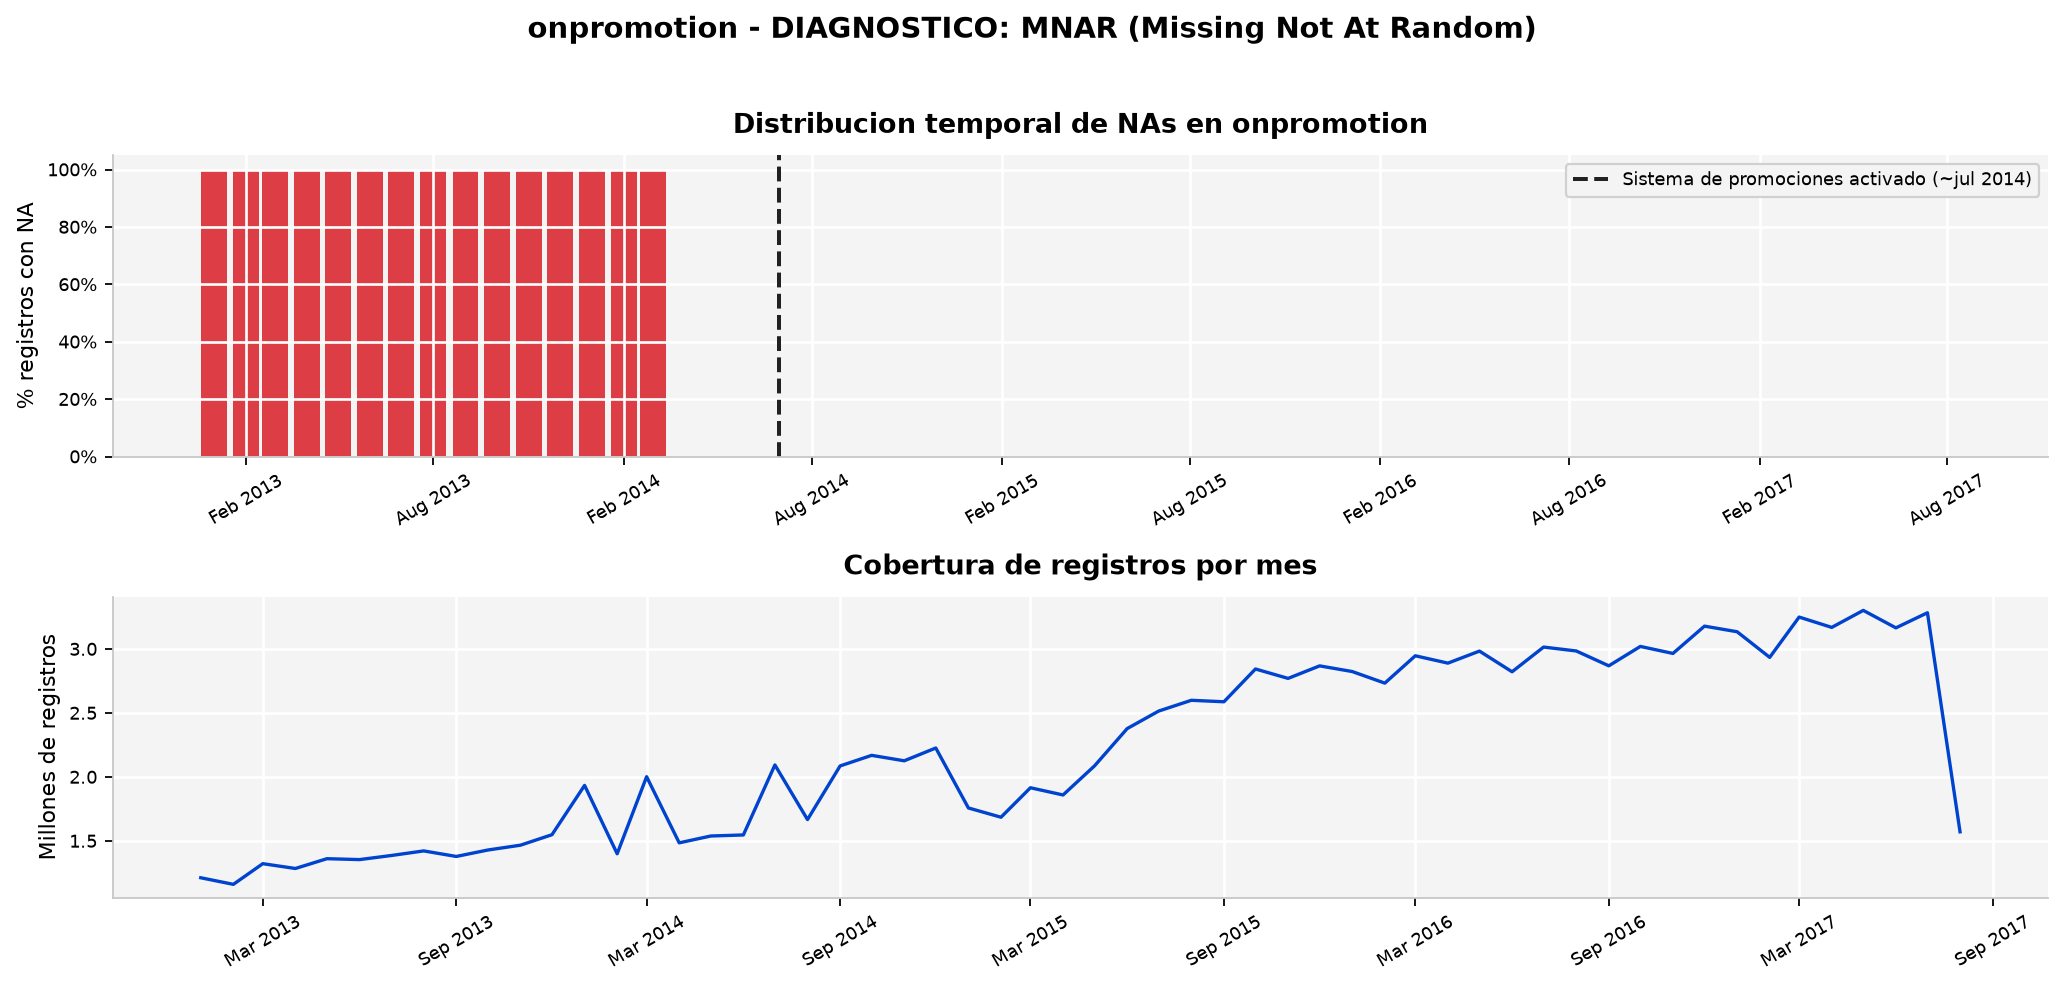

DIAGNOSTICO: MNAR
Los NAs se concentran ANTES de julio 2014. El sistema de captura
de promociones no existia. Imputar como False sesga el ATE.


In [5]:
# 2.1 onpromotion: clasificacion del mecanismo de faltantes
promo_na_ts = con.execute(
    "SELECT DATE_TRUNC('month', date) mes, "
    "COUNT(*) FILTER(WHERE onpromotion IS NULL) * 1.0 / COUNT(*) pct_na, "
    "COUNT(*) total FROM sales GROUP BY 1 ORDER BY 1").df()
promo_na_ts["mes"] = pd.to_datetime(promo_na_ts["mes"])

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].bar(promo_na_ts["mes"], promo_na_ts["pct_na"] * 100,
            width=25, color=PAL["red"], alpha=0.85)
axes[0].axvline(pd.Timestamp("2014-07-01"), color=PAL["ink"], ls="--", lw=1.8,
                label="Sistema de promociones activado (~jul 2014)")
axes[0].set_ylabel("% registros con NA")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title("Distribucion temporal de NAs en onpromotion")
axes[0].legend()

axes[1].plot(promo_na_ts["mes"], promo_na_ts["total"] / 1e6,
             color=PAL["blue"], lw=1.5)
axes[1].set_ylabel("Millones de registros")
axes[1].set_title("Cobertura de registros por mes")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("onpromotion - DIAGNOSTICO: MNAR (Missing Not At Random)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_mnar_onpromotion.png", bbox_inches="tight")
plt.show()

print("DIAGNOSTICO: MNAR")
print("Los NAs se concentran ANTES de julio 2014. El sistema de captura")
print("de promociones no existia. Imputar como False sesga el ATE.")


### Interpretación: *onpromotion* es MNAR

La distribución temporal de valores faltantes confirma un mecanismo MNAR. Antes de julio de
2014, el 100% de los registros tiene *onpromotion = NaN*, sin ningún valor *True* o *False*
en ese período. Después de julio de 2014, la tasa de valores faltantes cae abruptamente a 0%.

Este patrón de todo o nada es la firma de un cambio de infraestructura: el sistema de captura
de promociones se implementó alrededor de julio de 2014, de modo que los valores faltantes no
representan datos perdidos en el sentido estadístico habitual, sino la ausencia del
instrumento de medición.

Imputar estos valores como *False* introduciría un sesgo de medición, pues equivaldría a
asumir que no hubo promociones antes de 2014 cuando en realidad no se registraron. La
estrategia adecuada es crear una variable binaria *promo_tracked* que indique si el período
permite observar el estado promocional, y restringir los análisis causales de promociones al
período posterior a julio de 2014.

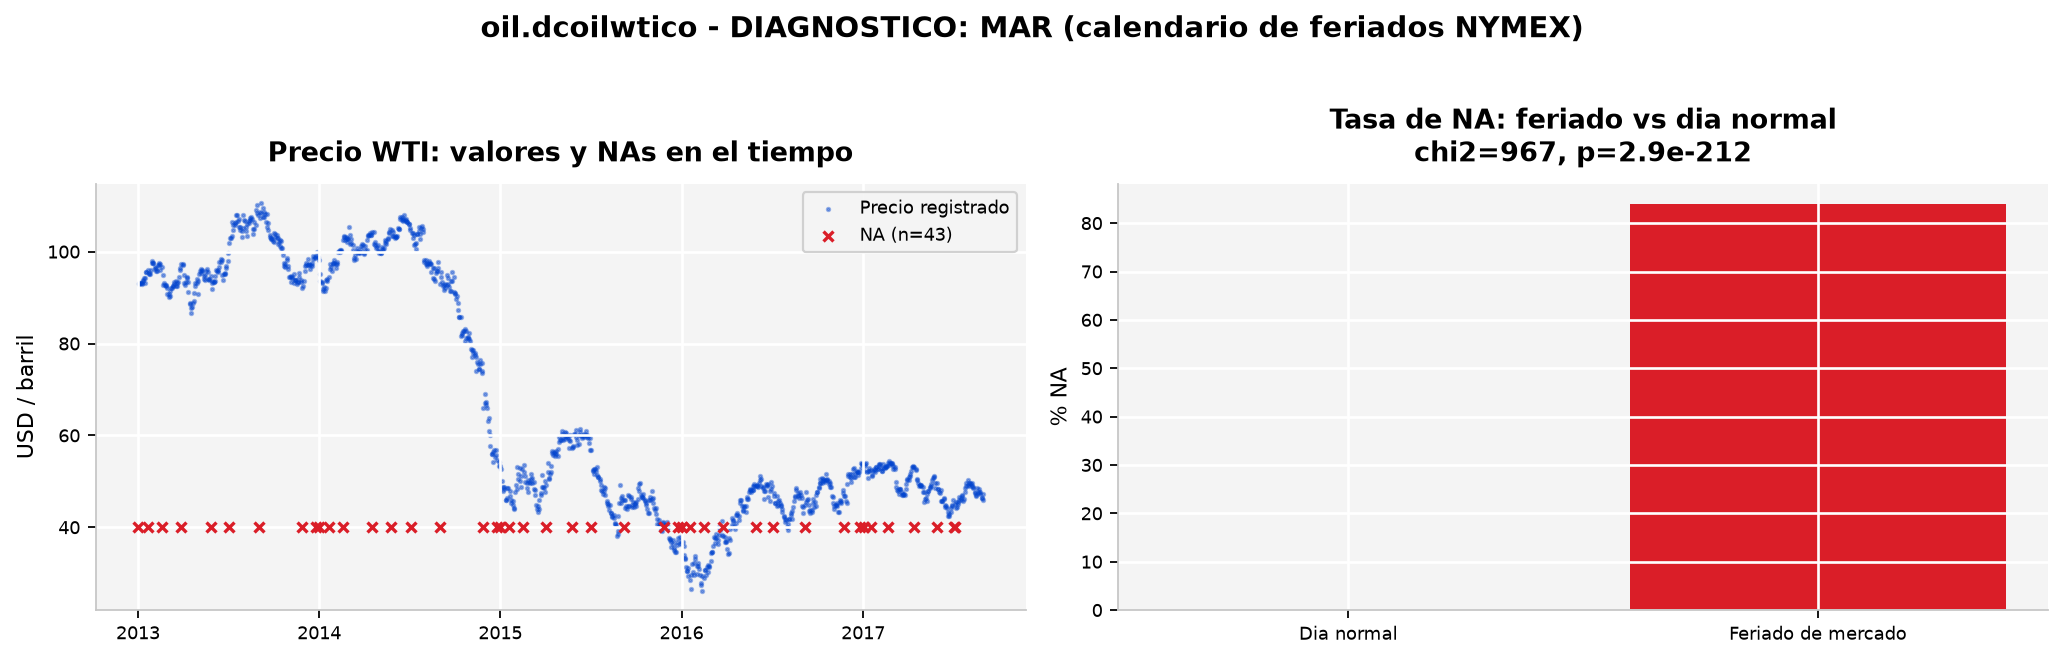

DIAGNOSTICO: MAR condicionado al calendario de mercado NYMEX
NAs que coinciden con feriado de mercado: 42 de 43
chi2=966.9, p=2.87e-212
LOCF es correcto: el precio no cambia si el mercado no opera.


In [6]:
# 2.2 oil.dcoilwtico: clasificacion del mecanismo de faltantes
from pandas.tseries.holiday import USFederalHolidayCalendar, GoodFriday

oil_raw = con.execute("SELECT date, dcoilwtico FROM oil ORDER BY date").df()
oil_raw["date"]  = pd.to_datetime(oil_raw["date"])
oil_raw["is_na"] = oil_raw["dcoilwtico"].isna()

# El WTI solo cotiza en dias habiles de mercado; no existen filas de fin de semana.
# Para diagnosticar el mecanismo contrastamos la ausencia de dato contra el
# calendario de feriados de mercado de EE.UU. (federales + Viernes Santo).
cal_ini, cal_fin = oil_raw["date"].min(), oil_raw["date"].max()
festivos = (pd.DatetimeIndex(USFederalHolidayCalendar().holidays(cal_ini, cal_fin))
              .union(pd.DatetimeIndex(GoodFriday.dates(cal_ini, cal_fin))))
oil_raw["is_holiday"] = oil_raw["date"].isin(festivos)

# Test chi-cuadrado: la ausencia de dato depende del calendario de feriados?
ct = pd.crosstab(oil_raw["is_holiday"], oil_raw["is_na"])
chi2, p = stats.chi2_contingency(ct)[:2]
n_na          = int(oil_raw["is_na"].sum())
n_na_festivo  = int((oil_raw["is_na"] & oil_raw["is_holiday"]).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(
    oil_raw[~oil_raw["is_na"]]["date"],
    oil_raw[~oil_raw["is_na"]]["dcoilwtico"],
    s=2, alpha=0.4, color=PAL["blue"], label="Precio registrado")
axes[0].scatter(
    oil_raw[oil_raw["is_na"]]["date"],
    [40] * n_na,
    s=20, color=PAL["red"], marker="x", label=f"NA (n={n_na})", zorder=5)
axes[0].set_title("Precio WTI: valores y NAs en el tiempo")
axes[0].set_ylabel("USD / barril")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

na_normal  = oil_raw[~oil_raw["is_holiday"]]["is_na"].mean() * 100
na_festivo = oil_raw[oil_raw["is_holiday"]]["is_na"].mean() * 100
axes[1].bar(["Dia normal", "Feriado de mercado"], [na_normal, na_festivo],
            color=[PAL["gray"], PAL["red"]])
axes[1].set_ylabel("% NA")
axes[1].set_title(f"Tasa de NA: feriado vs dia normal\nchi2={chi2:.0f}, p={p:.1e}")

plt.suptitle("oil.dcoilwtico - DIAGNOSTICO: MAR (calendario de feriados NYMEX)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("DIAGNOSTICO: MAR condicionado al calendario de mercado NYMEX")
print(f"NAs que coinciden con feriado de mercado: {n_na_festivo} de {n_na}")
print(f"chi2={chi2:.1f}, p={p:.2e}")
print("LOCF es correcto: el precio no cambia si el mercado no opera.")

### Interpretación: *oil.dcoilwtico* es MAR

El precio del petróleo WTI se registra únicamente en los días en que opera el mercado NYMEX,
por lo que la tabla no contiene filas de fin de semana. De los 43 valores faltantes, 42
coinciden con feriados de mercado de Estados Unidos y el restante, 3 de julio de 2017,
corresponde a la víspera del Día de la Independencia, una jornada de cierre anticipado. La
concentración de faltantes en lunes se explica porque varios feriados estadounidenses caen
siempre en lunes: el Día de Martin Luther King, el Día de los Presidentes, el Día de los
Caídos y el Día del Trabajo.

El test chi-cuadrado sobre la tabla de contingencia entre día feriado y valor faltante arroja
$\chi^2 \approx 966.9$ con $p < 10^{-200}$, lo que confirma una asociación fuerte entre la
ausencia de dato y el calendario de feriados. Dado que la probabilidad de que un dato falte
depende de una variable observable, el calendario de mercado, el mecanismo se clasifica como
MAR.

Dado que el precio del petróleo no cambia mientras el mercado está cerrado, la imputación por
arrastre del último valor observado, Last Observation Carried Forward, es la estrategia
óptima: el precio del último día hábil persiste hasta la reapertura. Esta decisión se respalda
en la literatura de finanzas empíricas de Campbell, Lo y MacKinlay (1997).

## 3. Pipeline de Procesamiento: Decisiones Metodológicas

Cada transformación aplicada a los datos crudos está justificada por un argumento estadístico
o de dominio, no por conveniencia. La siguiente tabla resume las decisiones tomadas junto con
la referencia que las respalda. El principio rector es conservar la máxima fidelidad a los
datos originales y marcar las anomalías en lugar de eliminarlas.

| Campo | Problema | Decisión | Fundamento |
|---|---|---|---|
| *onpromotion* | VARCHAR, 21.6M NAs, MNAR | Indicador *promo_tracked* | Little y Rubin (2002): no imputar bajo MNAR |
| *oil.dcoilwtico* | 43 NAs en feriados NYMEX | Last Observation Carried Forward | Campbell et al. (1997): precio persistente |
| *unit_sales < 0* | 7,795 devoluciones | Conservar y marcar *is_return* | Syntetos y Boylan (2005): demanda intermitente |
| *transactions* | ~8,600 días-tienda ausentes | Left join y clasificación | Cruce con *holidays_events* |
| *perishable* | BIGINT en vez de BOOLEAN | Conversión a booleano | Corrección de tipo sin pérdida de información |

In [7]:
# 3.1 Tablas de referencia (pequenas - cargar a pandas)
stores = con.execute("SELECT * FROM stores").df()
items  = con.execute("SELECT * FROM items").df()
hols   = con.execute("SELECT * FROM holidays_events").df()
hols["date"] = pd.to_datetime(hols["date"])

# Correcciones de tipo
stores["cluster"]   = stores["cluster"].astype(int)
items["perishable"] = items["perishable"].astype(bool)

# 3.2 Oil: LOCF
oil = con.execute("SELECT date, dcoilwtico FROM oil ORDER BY date").df()
oil["date"]       = pd.to_datetime(oil["date"])
oil["dcoilwtico"] = oil["dcoilwtico"].ffill()
oil["oil_7d_avg"] = oil["dcoilwtico"].rolling(7, min_periods=1).mean()

# 3.3 Macro Ecuador (Banco Mundial)
# ipc_var_pct    : inflacion anual Ecuador / 12 (tasa mensual equivalente, %)
# remesas_usd_mm : remesas recibidas Ecuador en millones USD (estimacion mensual)
# Fuente: World Bank API, indicadores FP.CPI.TOTL.ZG y BX.TRF.PWKR.CD.DT
macro_ecu = pd.read_csv(ECU_MACRO_PATH, parse_dates=["fecha"])

# 3.4 Ventas mensuales + macro combinado
oil["month"]   = oil["date"].dt.to_period("M").dt.to_timestamp()
oil_monthly    = oil.groupby("month")["dcoilwtico"].mean().reset_index()
oil_monthly.columns = ["fecha", "oil_price"]

sales_monthly = con.execute(
    "SELECT DATE_TRUNC('month', date) fecha, "
    "ROUND(SUM(unit_sales), 0) ventas_totales, "
    "ROUND(SUM(CASE WHEN unit_sales < 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4) pct_dev "
    "FROM sales WHERE unit_sales IS NOT NULL GROUP BY 1 ORDER BY 1").df()
sales_monthly["fecha"] = pd.to_datetime(sales_monthly["fecha"])

macro = (sales_monthly
    .merge(oil_monthly, on="fecha", how="left")
    .merge(macro_ecu,   on="fecha", how="left")
    .dropna(subset=["oil_price"]))

print(f"stores.cluster   -> int OK")
print(f"items.perishable -> bool OK")
print(f"oil LOCF         -> {oil['dcoilwtico'].isna().sum()} NAs restantes")
print(f"Tabla macro      -> {len(macro)} meses, {macro.shape[1]} columnas")
print(macro[["fecha","oil_price","ipc_var_pct","remesas_usd_mm"]].head(4).to_string(index=False))

stores.cluster   -> int OK
items.perishable -> bool OK
oil LOCF         -> 1 NAs restantes
Tabla macro      -> 56 meses, 6 columnas
     fecha  oil_price  ipc_var_pct  remesas_usd_mm
2013-01-01  94.795455     0.226815      204.900257
2013-02-01  95.341000     0.226815      204.900257
2013-03-01  93.143333     0.226815      204.900257
2013-04-01  92.021364     0.226815      204.900257


### Verificación del pipeline

El campo *stores.cluster* quedó convertido
a entero sin pérdida de información, y *items.perishable* quedó convertido a booleano con los
4,100 productos correctamente clasificados. De los 43 valores faltantes originales en el
precio del petróleo, 42 se imputaron por arrastre; el único valor faltante restante
corresponde al primer registro de la serie, que no tiene observación previa de la cual
arrastrar, un resultado esperado. La tabla macroeconómica resultante del merge contiene 56
meses válidos con seis columnas, cubriendo el período en que todas las fuentes, ventas,
petróleo y Banco Mundial, tienen datos simultáneos.

## 4. Análisis Distribucional

La distribución empírica de la variable objetivo, *unit_sales*, condiciona múltiples
decisiones de modelado: la elección de la función de enlace en modelos lineales
generalizados, la transformación apropiada para estabilizar la varianza y la selección de la
función de pérdida. Las ventas de retail siguen típicamente una distribución log-normal o
binomial negativa sobredispersada, no una distribución normal. Esta sección verifica esa
hipótesis mediante histogramas, ajuste paramétrico, gráfico Q-Q y el test de Shapiro-Wilk, y
evalúa además la concentración de ventas mediante el análisis de Pareto y la heterogeneidad
por tipo de tienda.

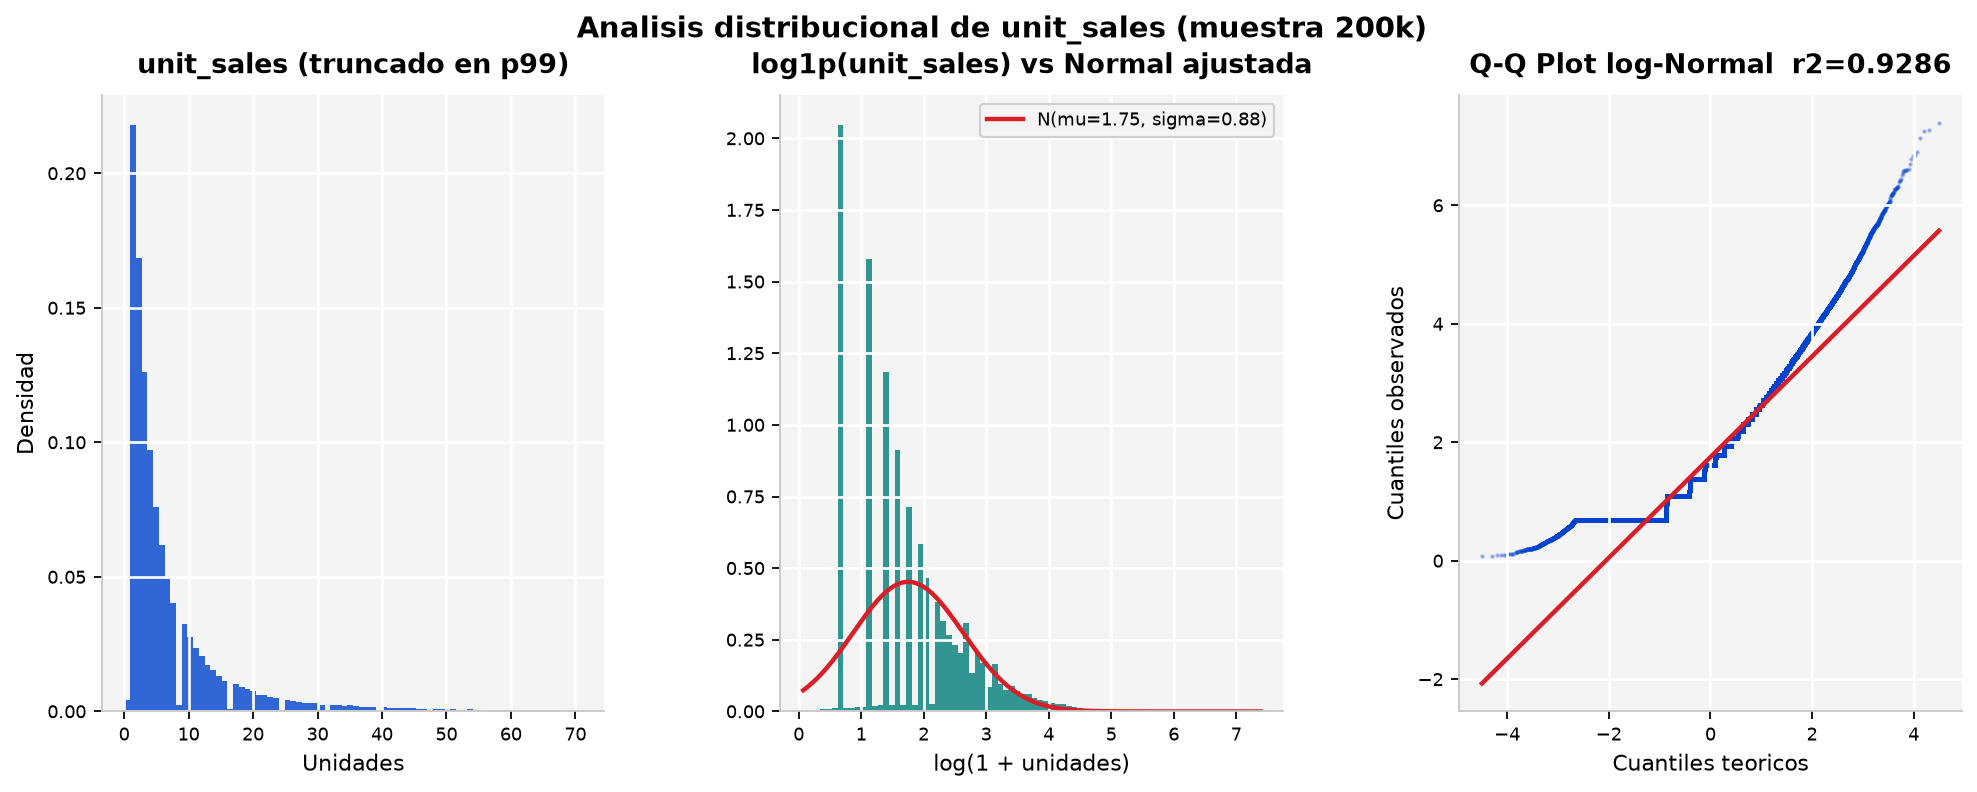

Shapiro-Wilk en log1p(sales): W=0.9295, p=1.63e-43
r2 Q-Q: 0.9286 -> Log-Normal es aproximacion razonable


In [8]:
# 4.1 Distribucion: Log-Normal vs Normal en log-escala
sample = con.execute(
    "SELECT unit_sales FROM sales WHERE unit_sales > 0 AND id % 625 = 0"
    ).df()["unit_sales"].values

fig = plt.figure(figsize=(15, 5))
gs  = GridSpec(1, 3, fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
p99 = np.percentile(sample, 99)
ax1.hist(sample[sample < p99], bins=80, color=PAL["blue"], alpha=0.8, density=True)
ax1.set_title("unit_sales (truncado en p99)")
ax1.set_xlabel("Unidades"); ax1.set_ylabel("Densidad")

ax2 = fig.add_subplot(gs[1])
log_s = np.log1p(sample)
ax2.hist(log_s, bins=80, color=PAL["teal"], alpha=0.8, density=True)
mu, sigma = log_s.mean(), log_s.std()
x = np.linspace(log_s.min(), log_s.max(), 300)
ax2.plot(x, stats.norm.pdf(x, mu, sigma), color=PAL["red"], lw=2,
         label=f"N(mu={mu:.2f}, sigma={sigma:.2f})")
ax2.set_title("log1p(unit_sales) vs Normal ajustada")
ax2.set_xlabel("log(1 + unidades)"); ax2.legend()

ax3 = fig.add_subplot(gs[2])
(osm, osr), (slope, intercept, r) = stats.probplot(log_s, dist="norm")
ax3.scatter(osm, osr, s=1, alpha=0.3, color=PAL["blue"])
x_line = np.array([osm.min(), osm.max()])
ax3.plot(x_line, slope * x_line + intercept, color=PAL["red"], lw=2)
ax3.set_title(f"Q-Q Plot log-Normal  r2={r**2:.4f}")
ax3.set_xlabel("Cuantiles teoricos"); ax3.set_ylabel("Cuantiles observados")

plt.suptitle("Analisis distribucional de unit_sales (muestra 200k)", fontsize=13)
plt.savefig(ROOT / "reports/fig_distribucion_ventas.png", bbox_inches="tight")
plt.show()

stat, p_sw = stats.shapiro(np.random.choice(log_s, 5000, replace=False))
print(f"Shapiro-Wilk en log1p(sales): W={stat:.4f}, p={p_sw:.2e}")
print(f"r2 Q-Q: {r**2:.4f} -> Log-Normal es aproximacion razonable")


### Interpretación del análisis distribucional

El histograma de *unit_sales*, en azul en el panel izquierdo, muestra una distribución
fuertemente asimétrica a la derecha, consistente con el comportamiento típico de la demanda
en retail: la mayoría de los registros concentra ventas bajas y una cola larga corresponde a
registros con ventas altas.

La transformación logarítmica $\log(1+x)$, panel central, simetriza sustancialmente la
distribución. La curva normal ajustada, trazada en rojo sobre el histograma en verde agua, con
$\mu = 1.75$ y $\sigma = 0.88$, se superpone razonablemente bien a los datos. El gráfico Q-Q
del panel derecho, con los cuantiles observados en azul frente a la línea de referencia en
rojo, arroja $r^2 = 0.93$, lo que indica que la aproximación log-normal es razonable, aunque
no exacta.

El test de Shapiro-Wilk rechaza formalmente la hipótesis de normalidad en la escala
logarítmica, con $W = 0.93$ y $p \approx 0$. Este resultado es esperado: con una muestra de
200,000 observaciones, incluso desviaciones triviales de la normalidad producen rechazo. Lo
relevante para el modelado no es la normalidad exacta sino que la transformación logarítmica
estabiliza la varianza y aproxima la homoscedasticidad de los residuos en un modelo lineal.

Vamos a optar por transformar la variable objetivo usando $\log(1+y)$. No obstante, si buscamos
 robustez, también podemos probar con un GLM de enlace logarítmico y familia Gamma o Binomial Negativa.

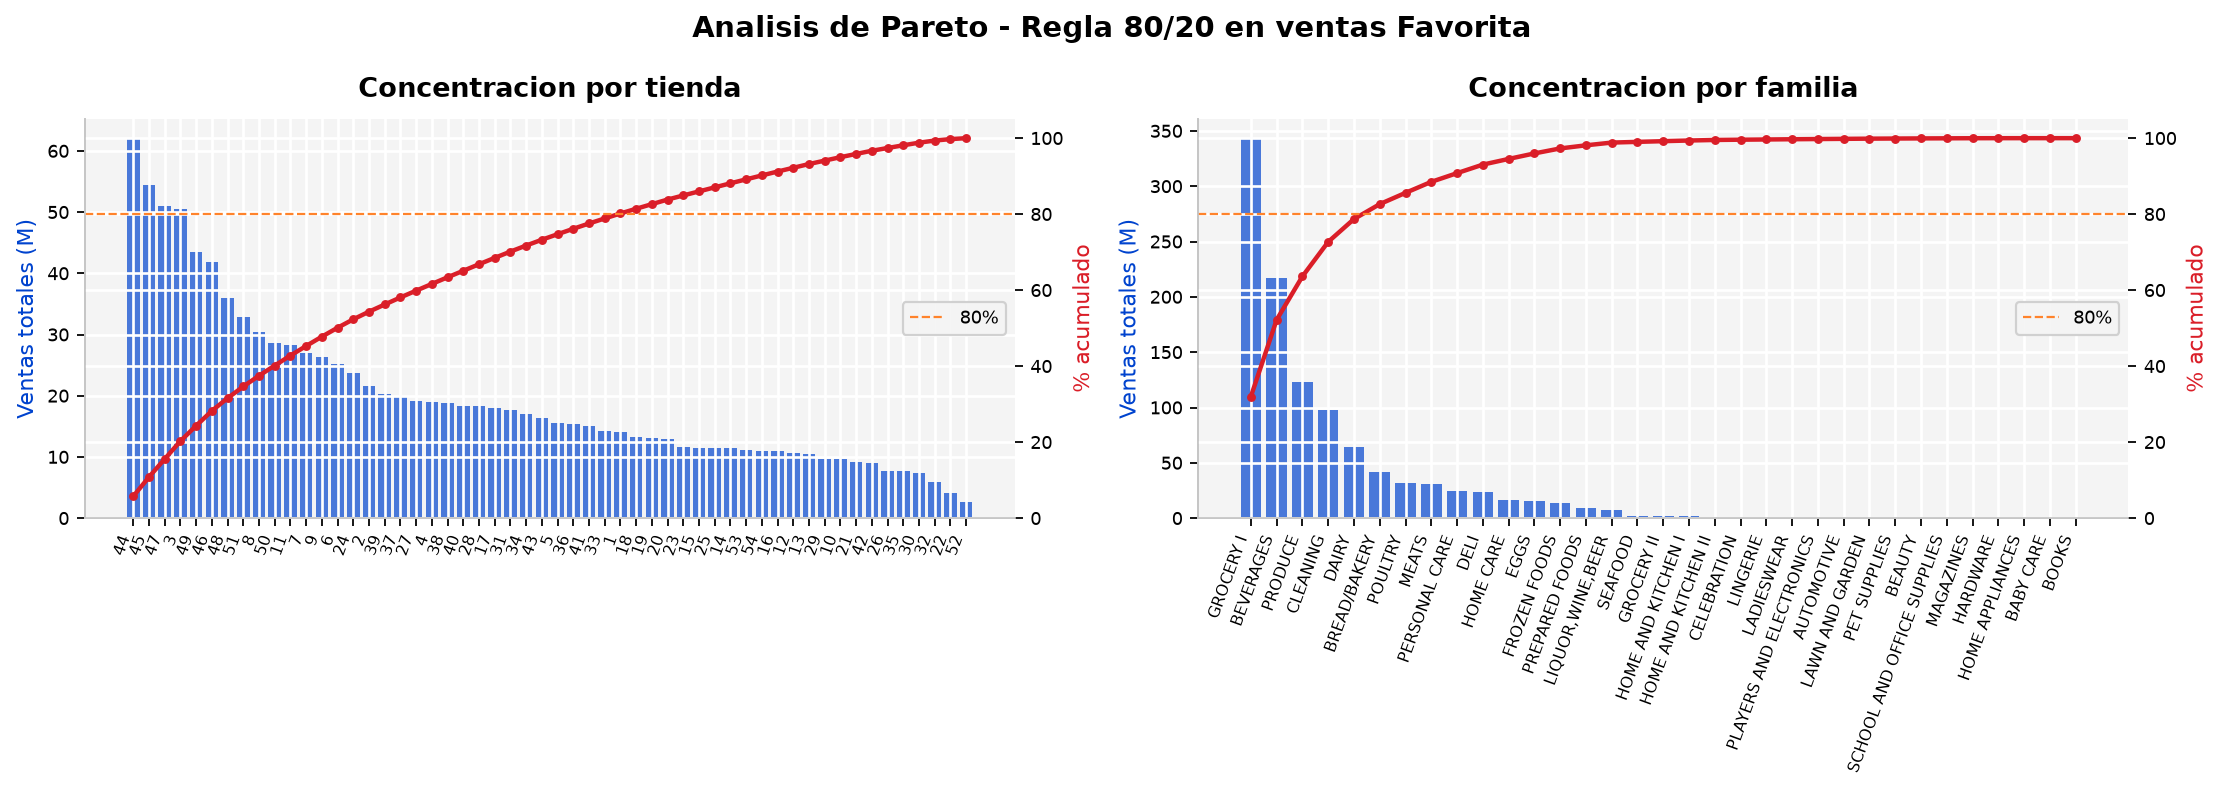

El 80% de ventas: 32/54 tiendas
El 80% de ventas: 6/33 familias


In [9]:
# 4.2 Analisis Pareto: concentracion de ventas 80/20
def pareto_df(query, label_col):
    df = con.execute(query).df()
    df["cumsum_pct"] = df["total"].cumsum() / df["total"].sum() * 100
    return df

pareto_stores = pareto_df(
    "SELECT s.store_nbr, st.type, ROUND(SUM(s.unit_sales),0) total "
    "FROM sales s JOIN stores st USING(store_nbr) WHERE unit_sales>0 "
    "GROUP BY 1,2 ORDER BY total DESC", "store_nbr")

pareto_fam = pareto_df(
    "SELECT i.family, ROUND(SUM(s.unit_sales),0) total "
    "FROM sales s JOIN items i USING(item_nbr) WHERE unit_sales>0 "
    "GROUP BY 1 ORDER BY total DESC", "family")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, label_col, title in [
    (axes[0], pareto_stores, "store_nbr", "Concentracion por tienda"),
    (axes[1], pareto_fam,   "family",    "Concentracion por familia"),
]:
    ax2 = ax.twinx()
    ax.bar(range(len(df)), df["total"] / 1e6, color=PAL["blue"], alpha=0.7)
    ax2.plot(range(len(df)), df["cumsum_pct"], color=PAL["red"], lw=2, marker="o", ms=3)
    ax2.axhline(80, color=PAL["orange"], ls="--", lw=1, label="80%")
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df[label_col].astype(str), rotation=70, ha="right", fontsize=7)
    ax.set_ylabel("Ventas totales (M)", color=PAL["blue"])
    ax2.set_ylabel("% acumulado", color=PAL["red"])
    ax2.set_ylim(0, 105)
    ax.set_title(title)
    ax2.legend(loc="center right")

plt.suptitle("Analisis de Pareto - Regla 80/20 en ventas Favorita", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_pareto.png", bbox_inches="tight")
plt.show()

n80_s = int((pareto_stores["cumsum_pct"] <= 80).sum()) + 1
n80_f = int((pareto_fam["cumsum_pct"]    <= 80).sum()) + 1
print(f"El 80% de ventas: {n80_s}/{len(pareto_stores)} tiendas")
print(f"El 80% de ventas: {n80_f}/{len(pareto_fam)} familias")


### Interpretación del análisis de Pareto

Las barras azules del panel de concentración muestran el volumen de ventas por tienda y por
familia, mientras que la línea roja traza el porcentaje acumulado y la línea naranja
discontinua marca el umbral del 80%. Por tienda, el 80% de las ventas se concentra en 32 de
54 tiendas, el 59% del total. Por familia de producto, el 80% de las ventas se
concentra en apenas 6 de 33 familias, el 18% del total, encabezadas por GROCERY I, BEVERAGES
y PRODUCE.

En lugar de modelar las 1,782combinaciones posibles entre 54 tiendas y 33 familias, los recursos 
computacionales pueden focalizarse en un subconjunto representativo que capture la mayor parte de 
la variabilidad del sistema.

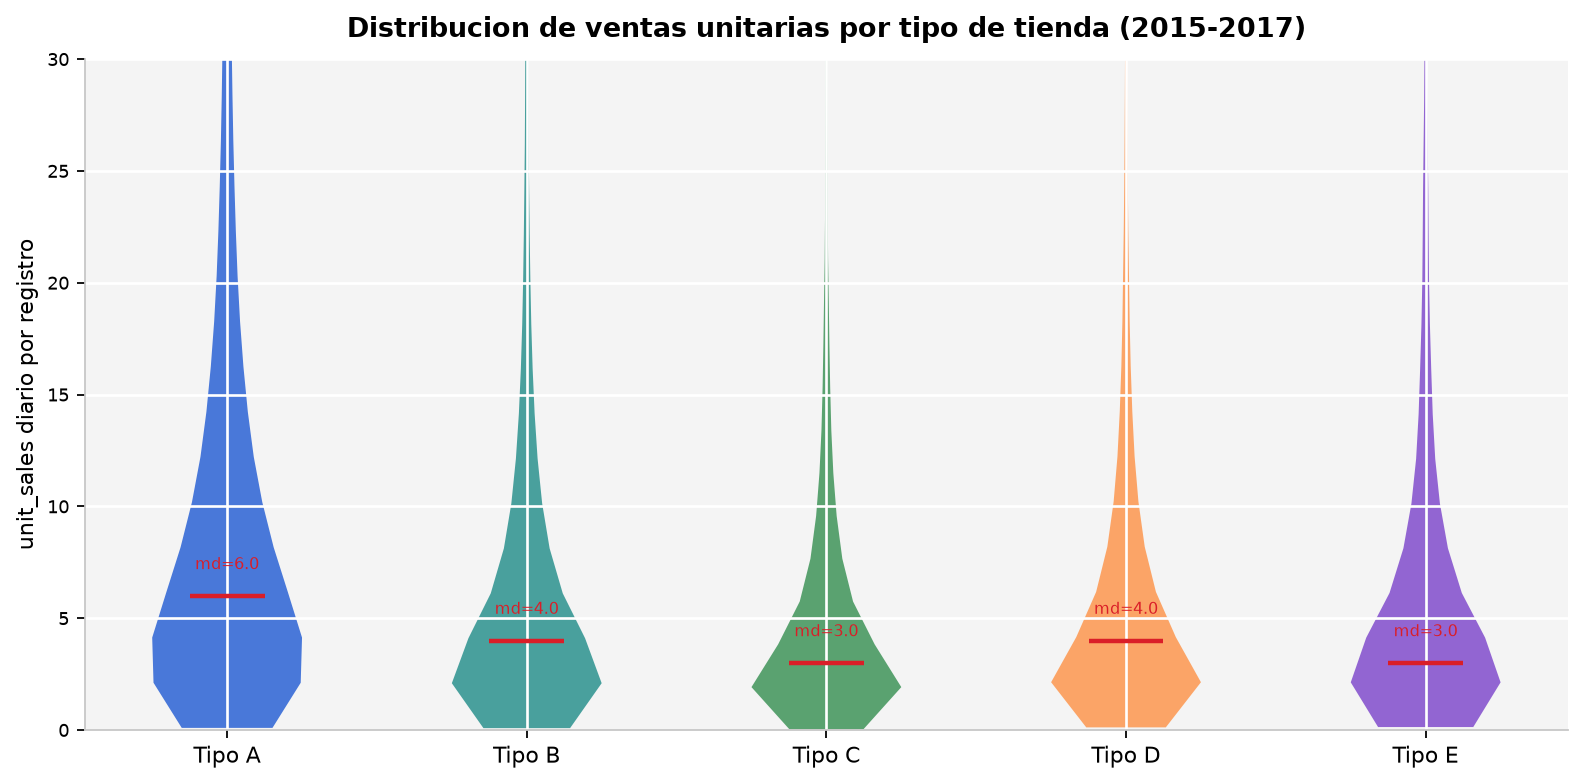

In [10]:
# 4.3 Violin plots por tipo de tienda
violin_data = con.execute(
    "SELECT st.type, s.unit_sales FROM sales s JOIN stores st USING(store_nbr) "
    "WHERE s.unit_sales BETWEEN 0 AND 200 AND s.date >= '2015-01-01' "
    "AND s.id % 417 = 0").df()

fig, ax = plt.subplots(figsize=(10, 5))
tipos = sorted(violin_data["type"].unique())
colors_v = [PAL["blue"], PAL["teal"], PAL["green"], PAL["orange"], PAL["purple"]]
data_v = [violin_data[violin_data["type"] == t]["unit_sales"].values for t in tipos]
parts  = ax.violinplot(data_v, positions=range(len(tipos)),
                       showmedians=True, showextrema=False)
for pc, col in zip(parts["bodies"], colors_v):
    pc.set_facecolor(col); pc.set_alpha(0.7)
parts["cmedians"].set_color(PAL["red"]); parts["cmedians"].set_linewidth(2)

ax.set_xticks(range(len(tipos)))
ax.set_xticklabels([f"Tipo {t}" for t in tipos], fontsize=10)
ax.set_ylabel("unit_sales diario por registro")
ax.set_title("Distribucion de ventas unitarias por tipo de tienda (2015-2017)")
# Recortar el eje al percentil 95 para ver la masa de la distribucion
y_max = float(np.ceil(violin_data["unit_sales"].quantile(0.95) / 5) * 5)
ax.set_ylim(0, y_max)

for i, t in enumerate(tipos):
    med = float(violin_data[violin_data["type"] == t]["unit_sales"].median())
    ax.text(i, med + y_max * 0.04, f"md={med:.1f}", ha="center", fontsize=7, color=PAL["red"])

plt.tight_layout()
plt.savefig(ROOT / "reports/fig_violin_tipo.png", bbox_inches="tight")
plt.show()


### Interpretación de las distribuciones por tipo de tienda

Los violines, coloreados por tipo de tienda con la mediana marcada en rojo, muestran
diferencias sistemáticas entre los cinco tipos A a E en la distribución de ventas unitarias.
Los tipos A, B y D presentan las medianas más altas, entre 4 y 6 unidades por registro, lo que
indica mayor volumen promedio por transacción. Los tipos C y E muestran distribuciones más
comprimidas con medianas más bajas, correspondientes a tiendas de menor formato.

Estas diferencias confirman que el tipo de tienda es un factor relevante de estratificación y
debe incluirse como variable de control en el modelo causal.

## 5. Estructura Temporal

La descomposición STL de Cleveland et al. (1990) separa una serie temporal en tendencia,
estacionalidad y residuo, de modo que $Y_t = T_t + S_t + R_t$, mediante regresiones LOESS que
le confieren mayor flexibilidad frente a métodos clásicos como la descomposición Census X-11.
La versión robusta reduce iterativamente el peso de observaciones atípicas, como feriados
nacionales y eventos promocionales masivos, en la estimación de tendencia y estacionalidad.

Esta sección aplica STL a la serie diaria de Tienda 44, GROCERY I, evalúa la autocorrelación
residual mediante ACF y PACF, verifica estacionariedad con el test de Dickey-Fuller Aumentado,
y examina los patrones de calendario mediante heatmaps anuales.

  Tendencia       : 18.2% de la varianza total
  Estacionalidad  : 47.0% de la varianza total
  Residuo         : 45.0% de la varianza total


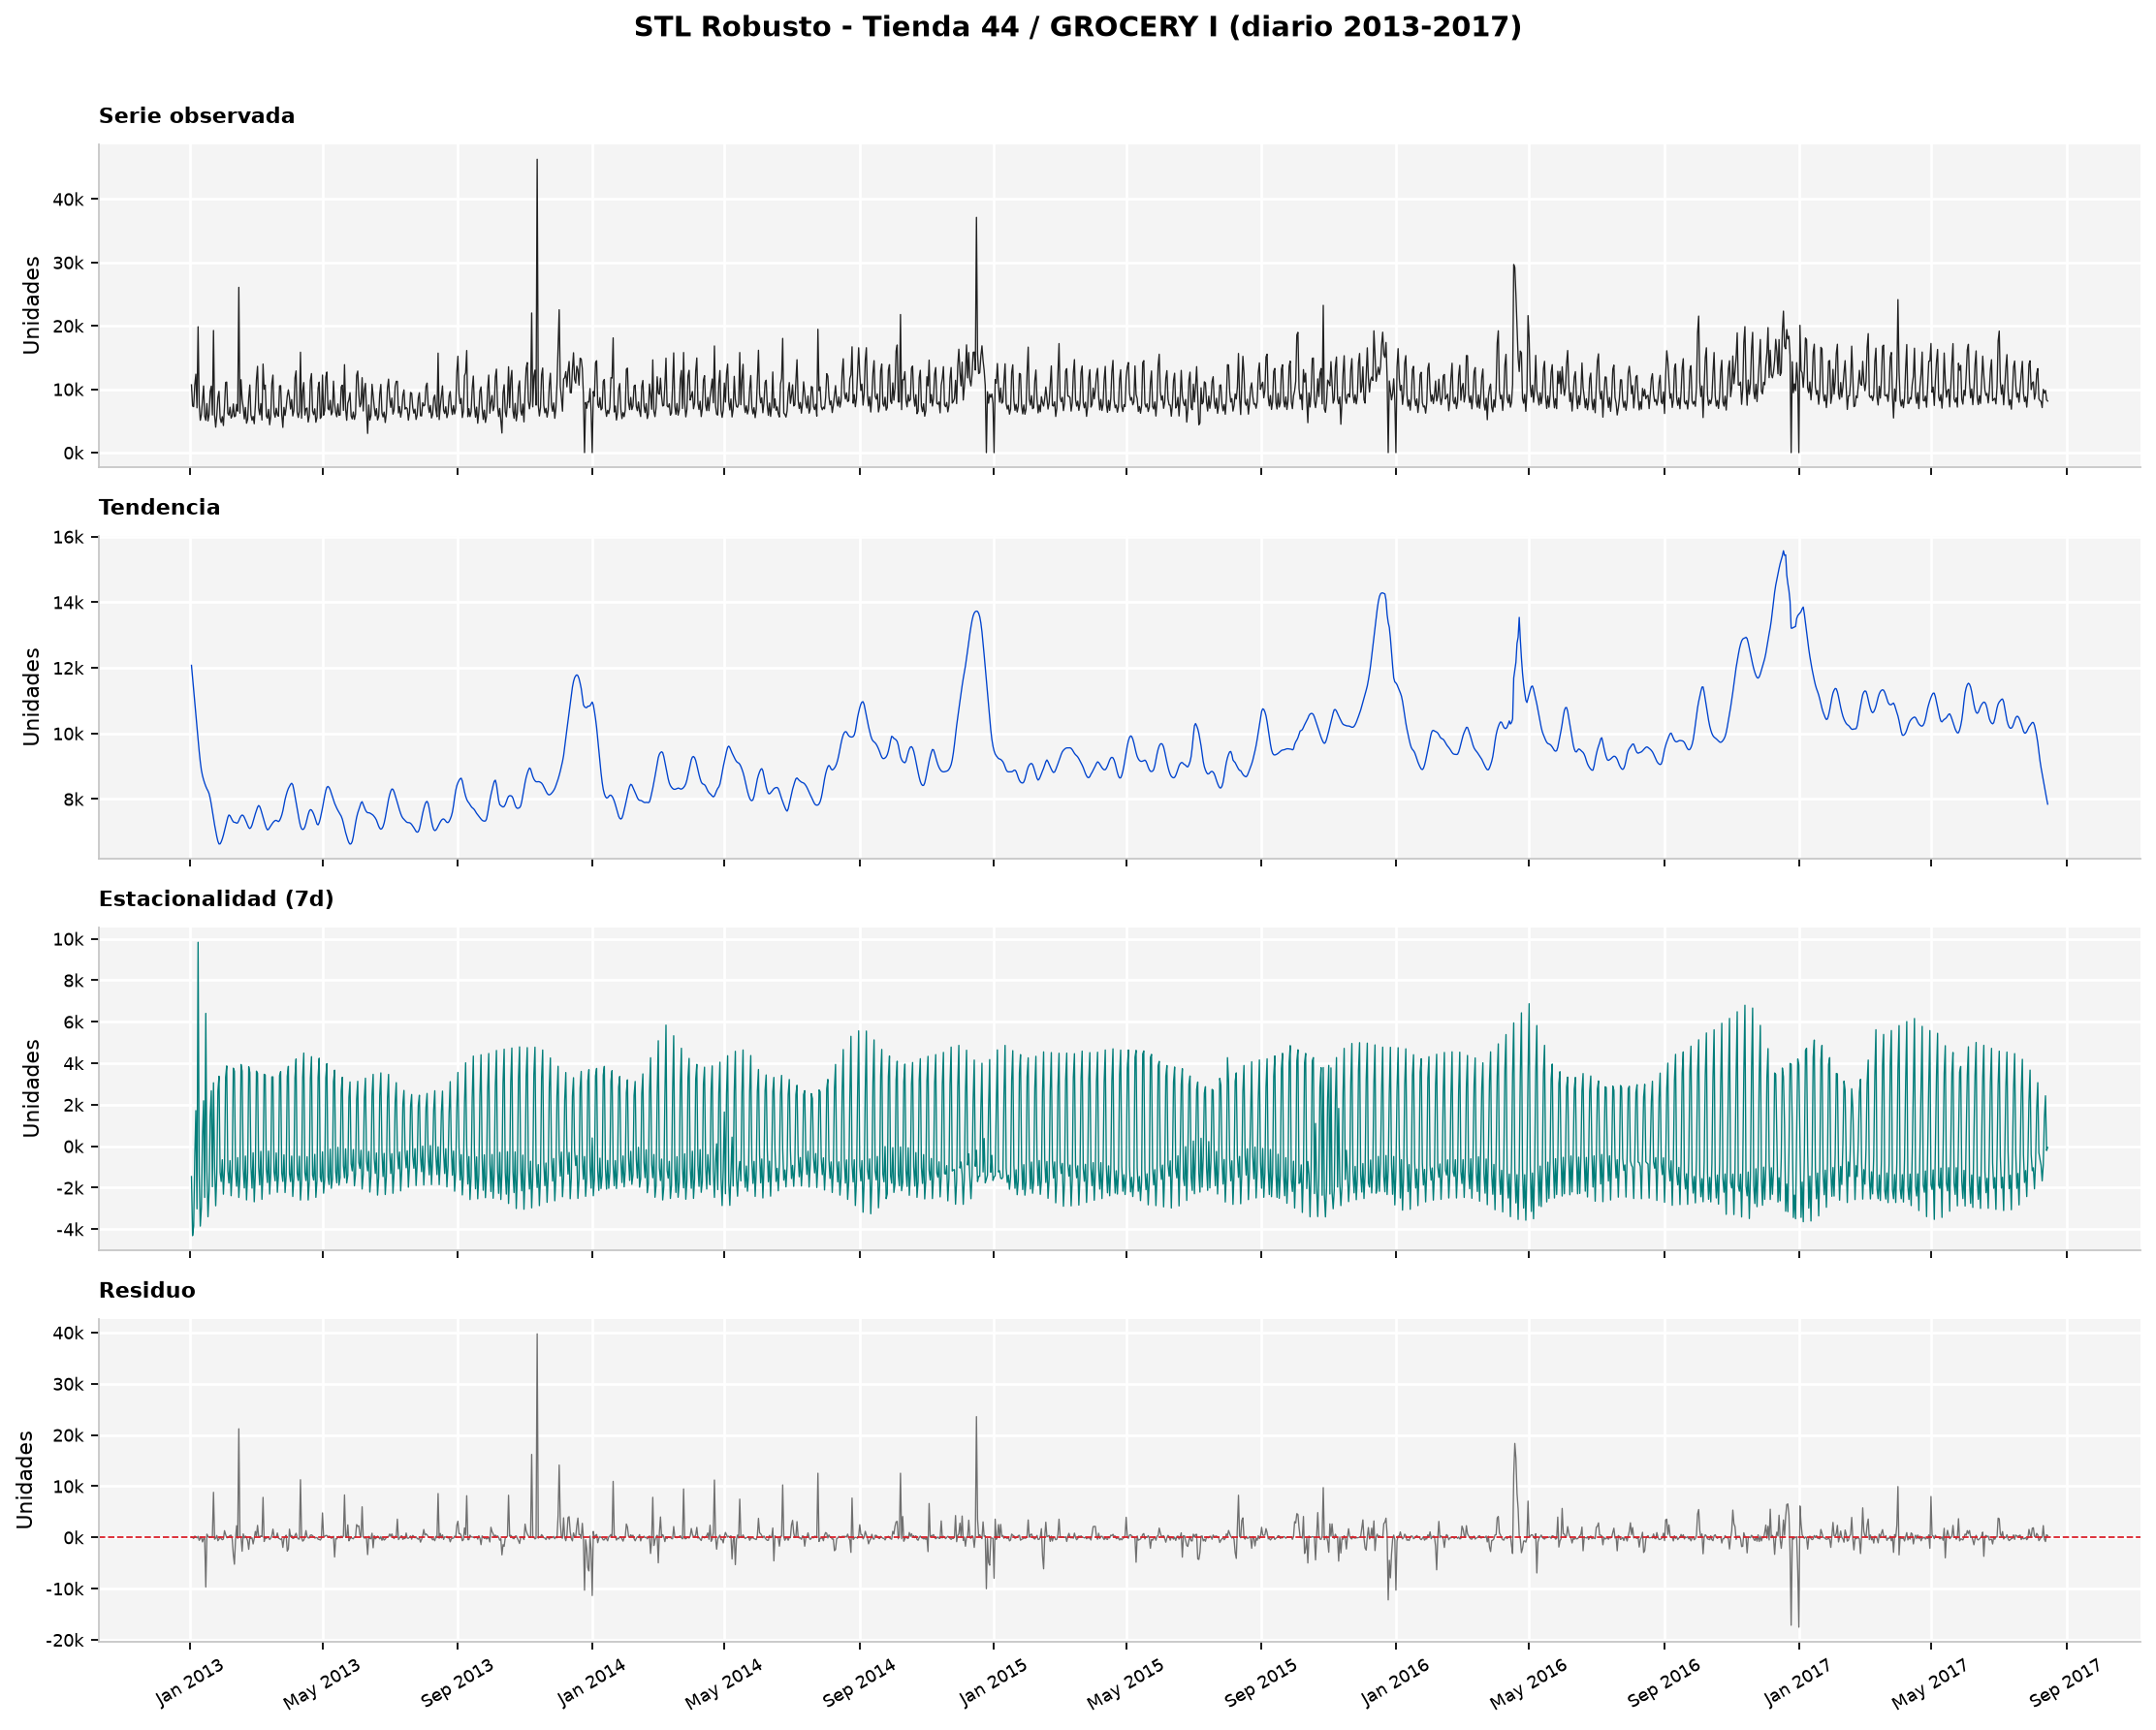

In [11]:
# 5.1 Descomposicion STL - Tienda 44 GROCERY I
daily_t44 = con.execute(
    "SELECT date, SUM(unit_sales) ventas FROM sales s JOIN items i USING(item_nbr) "
    "WHERE store_nbr=44 AND family='GROCERY I' AND unit_sales>=0 "
    "GROUP BY date ORDER BY date").df()
daily_t44["date"] = pd.to_datetime(daily_t44["date"])
daily_t44 = daily_t44.set_index("date").asfreq("D").fillna(0)

stl = STL(daily_t44["ventas"], period=7, robust=True)
res = stl.fit()

var_total = float(res.observed.var())
for name, comp in [("Tendencia", res.trend), ("Estacionalidad", res.seasonal), ("Residuo", res.resid)]:
    print(f"  {name:<16}: {comp.var()/var_total*100:.1f}% de la varianza total")

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
comps = [
    (res.observed,  "Serie observada",      PAL["ink"],  False),
    (res.trend,     "Tendencia",            PAL["blue"], False),
    (res.seasonal,  "Estacionalidad (7d)",  PAL["teal"], False),
    (res.resid,     "Residuo",              PAL["gray"], True),
]
for ax, (data, title, col, zero) in zip(axes, comps):
    ax.plot(data.index, data.values, color=col, lw=0.6 if len(data) > 500 else 1.2)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel("Unidades")
    if zero:
        ax.axhline(0, color=PAL["red"], lw=0.8, ls="--")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle("STL Robusto - Tienda 44 / GROCERY I (diario 2013-2017)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_stl_t44.png", bbox_inches="tight")
plt.show()


### Interpretación de la descomposición STL

Los cuatro paneles de la descomposición, serie observada en negro, tendencia en azul,
estacionalidad en verde agua y residuo en gris, muestran la estructura interna de la demanda
de Tienda 44 / GROCERY I a lo largo de 1,687 observaciones diarias.

La tendencia explica el 18.2% de la varianza y describe un crecimiento general desde 2013 
hasta finales de 2016, seguido de un marcado descenso en 2017. Cabe destacar que la tendencia 
captura picos anuales recurrentes, lo que evidencia que parte del comportamiento estacional anual 
se ha filtrado en este componente debido al nivel de suavizado del algoritmo. Aun así, el patrón 
de crecimiento a largo plazo es consistente con la fase de expansión de Corporación Favorita.

La estacionalidad explica el 47.0% de la varianza y es el componente dominante: el ciclo
semanal de 7 días explica casi la mitad de la variación total, con picos regulares los
sábados. Un modelo sin variables de día de la semana perdería casi la mitad de la señal
explicativa.

El residuo explica el 45.0% de la varianza, una magnitud que indica la presencia de factores
no capturados por la tendencia ni la estacionalidad semanal: feriados nacionales, promociones,
eventos locales y efectos de calendario no periódicos. La suma de los tres porcentajes excede
100% porque los componentes de la descomposición STL son aditivos pero no ortogonales.

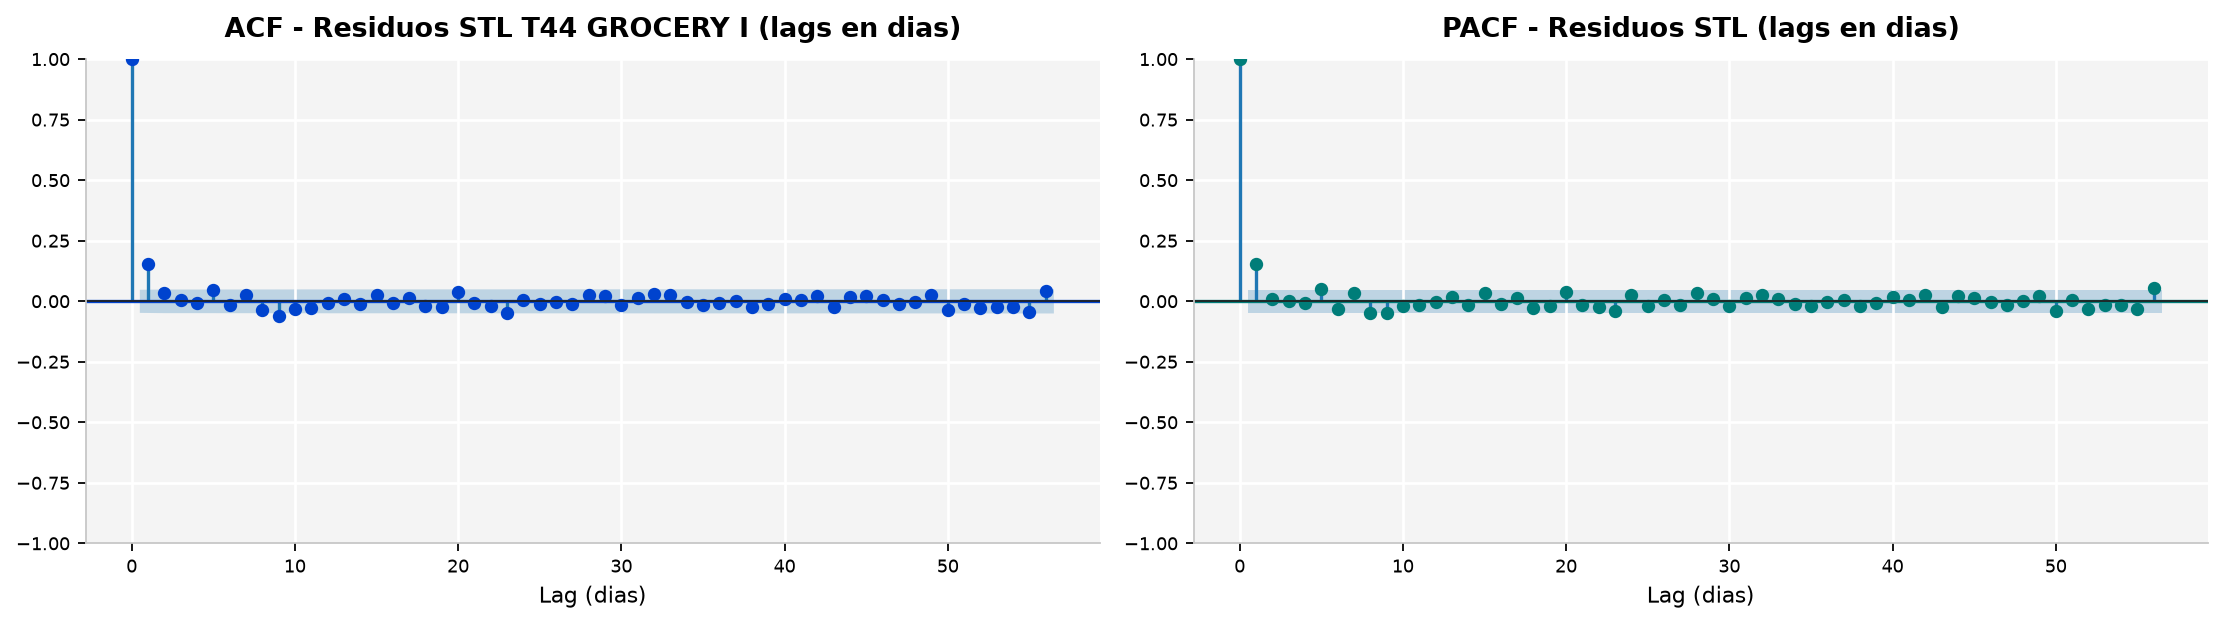

Test ADF residuos STL: estadistico=-14.100, p=0.0000
Residuos ESTACIONARIOS


In [13]:
# 5.2 ACF y PACF de los residuos STL
resid_s = res.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( resid_s, lags=56, ax=axes[0], color=PAL["blue"],
          title="ACF - Residuos STL T44 GROCERY I (lags en dias)")
plot_pacf(resid_s, lags=56, ax=axes[1], color=PAL["teal"], method="ywm",
          title="PACF - Residuos STL (lags en dias)")
for ax in axes:
    ax.axhline(0, color=PAL["ink"], lw=0.8)
    ax.set_xlabel("Lag (dias)")

plt.tight_layout()
plt.savefig(ROOT / "reports/fig_acf_pacf.png", bbox_inches="tight")
plt.show()

adf_stat, adf_p = adfuller(resid_s.dropna())[:2]
print(f"Test ADF residuos STL: estadistico={adf_stat:.3f}, p={adf_p:.4f}")
print("Residuos", "ESTACIONARIOS" if adf_p < 0.05 else "NO estacionarios - revisar")


### Interpretación de los correlogramas y del test de estacionariedad

El correlograma ACF, en azul, no muestra picos significativos, lo que confirma que la estacionalidad
de ciclo semanal fue removida de forma exitosa y casi completa por la descomposición STL. El
correlograma PACF, en verde agua, muestra únicamente un coeficiente significativo en el primer lag.
Por lo que los residuos se comportan prácticamente como ruido blanco, o que a lo sumo un modelo AR(1) o MA(1)
simple podría capturar la mínima estructura residual restante.

El test de Dickey-Fuller Aumentado sobre los residuos STL produce un estadístico de $-14.1$
con $p \approx 0$, que permite rechazar con alta confianza la hipótesis nula de raíz unitaria.
Los residuos son estacionarios, lo que confirma que la descomposición removió exitosamente la
tendencia no estacionaria y que la serie descompuesta es apta para el modelado de series
temporales.

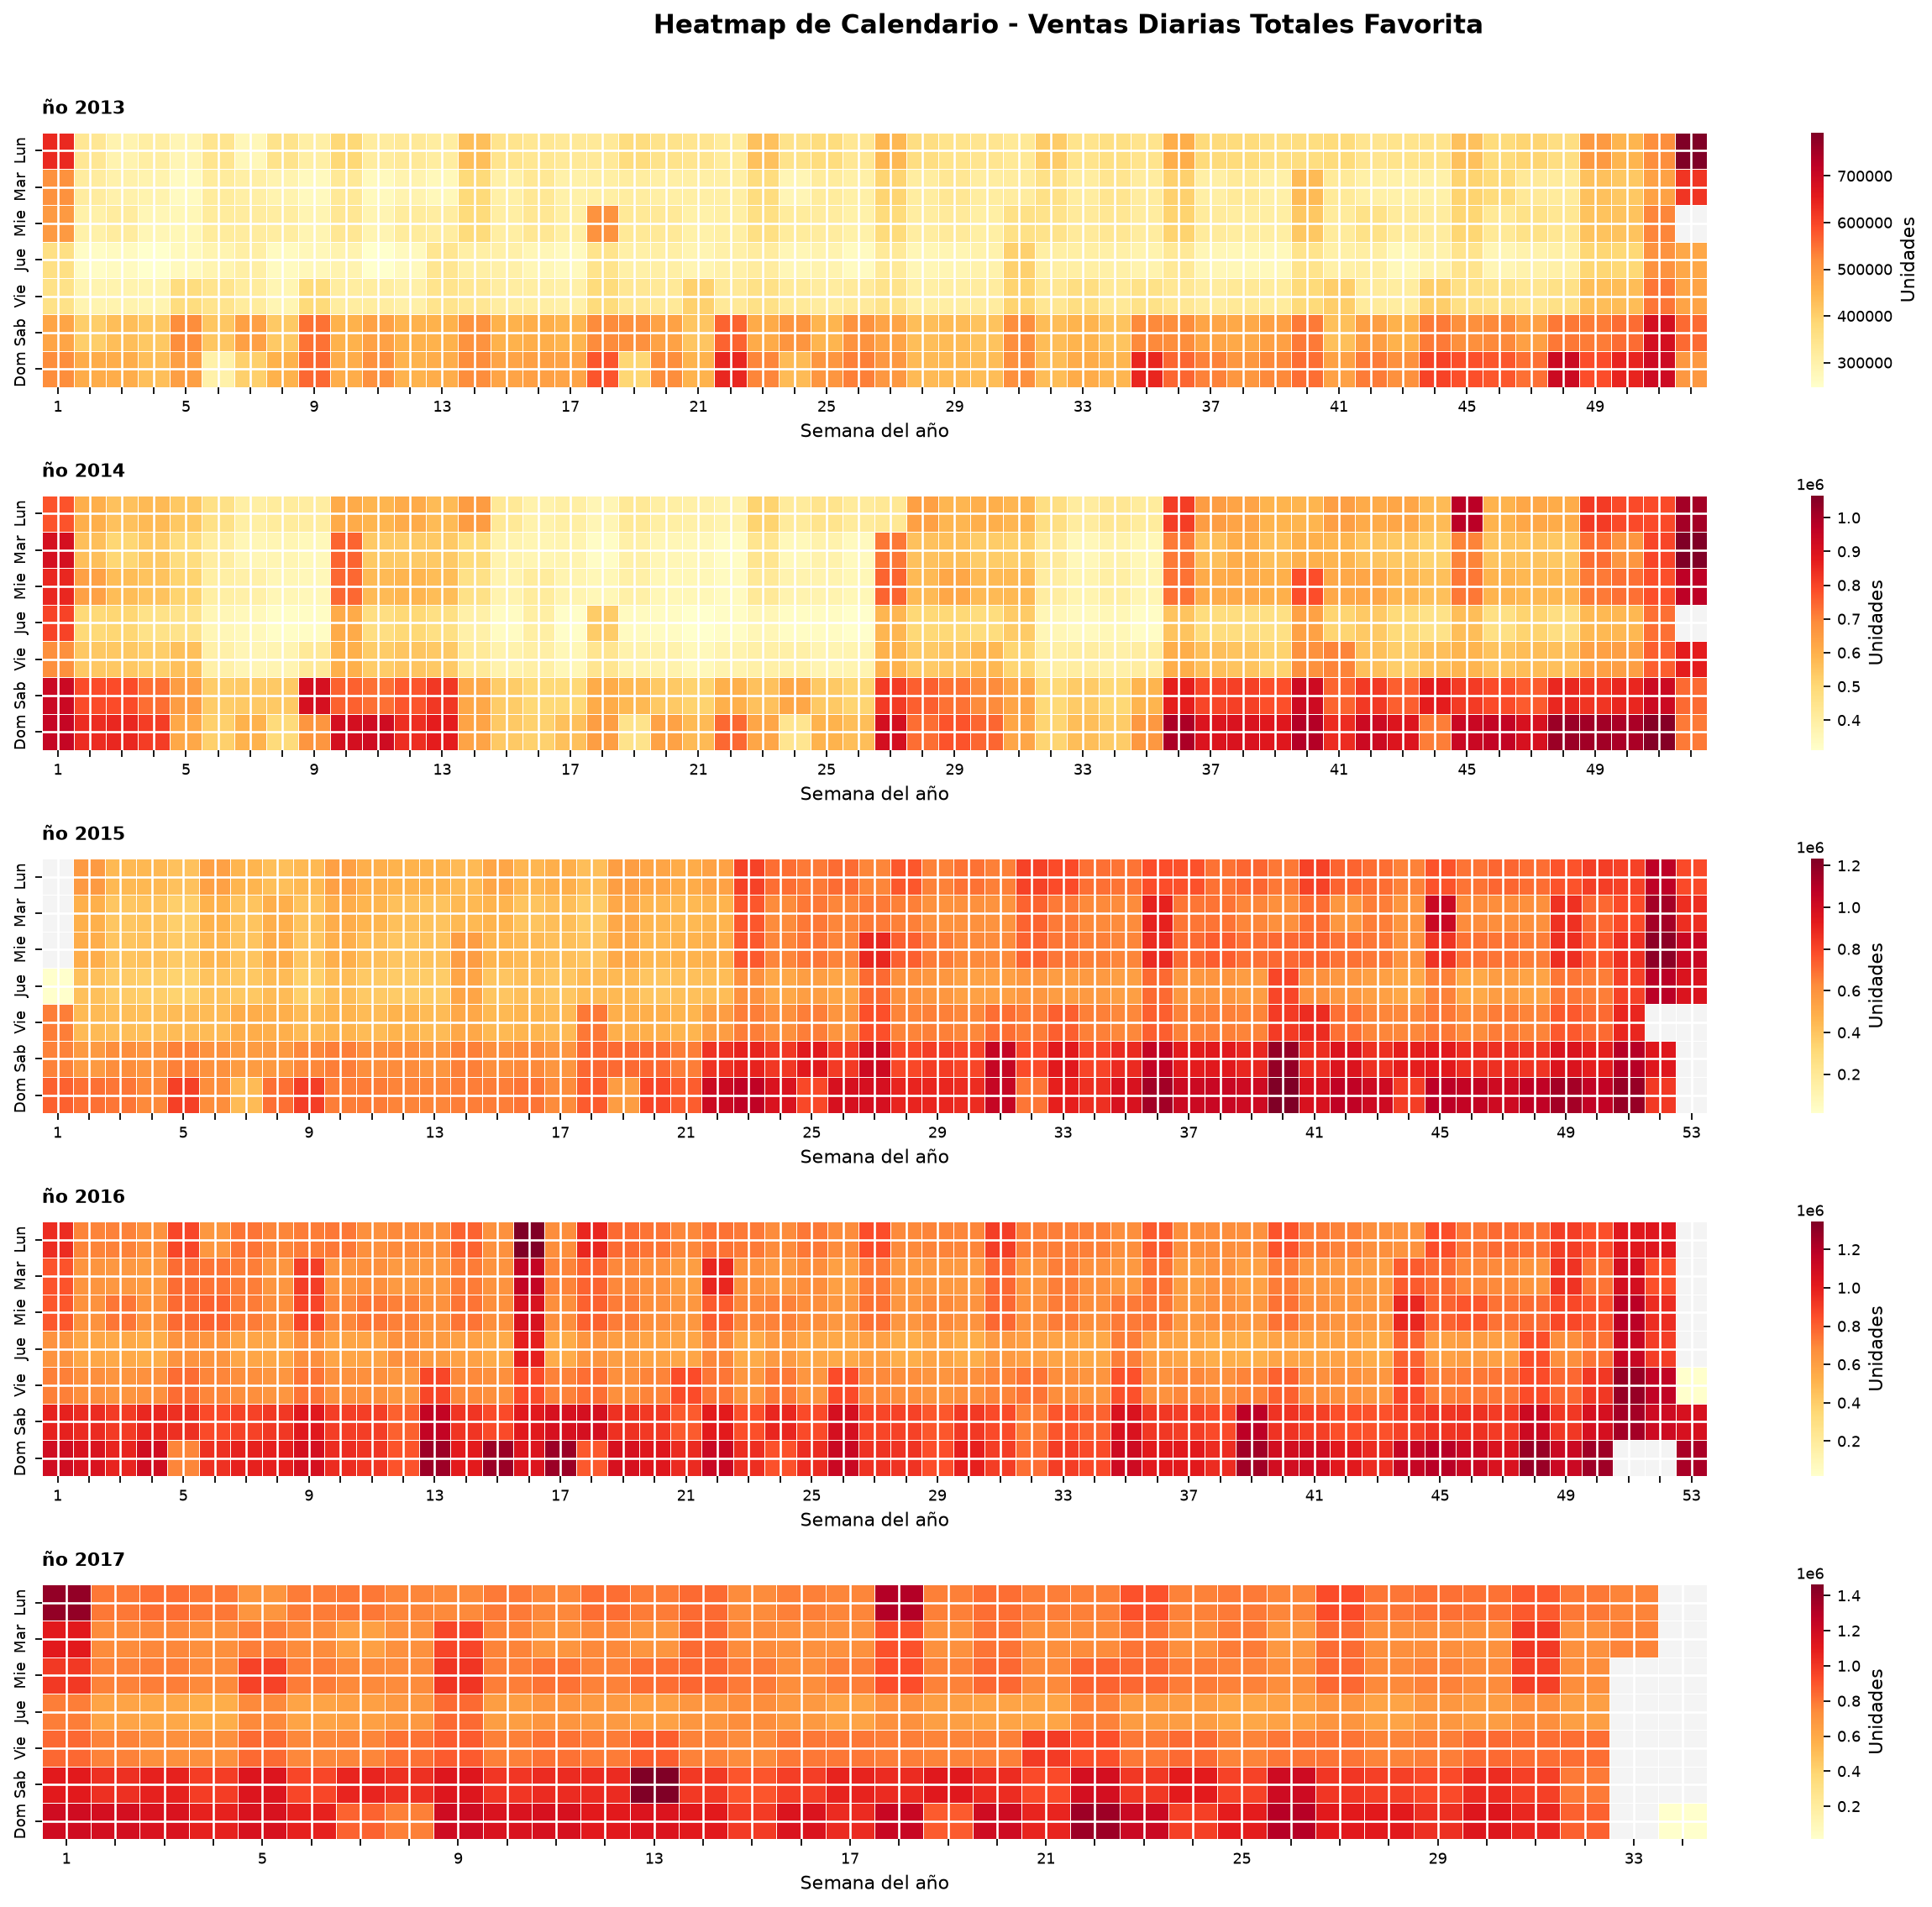

Patron visible: sabados sistematicamente mas intensos; diciembre = pico anual.


In [14]:
# 5.3 Heatmap de calendario - ventas diarias totales
daily_all = con.execute(
    "SELECT date, SUM(unit_sales) ventas FROM sales WHERE unit_sales>0 "
    "GROUP BY date ORDER BY date").df()
daily_all["date"]    = pd.to_datetime(daily_all["date"])
daily_all["year"]    = daily_all["date"].dt.year
daily_all["week"]    = daily_all["date"].dt.isocalendar().week.astype(int)
daily_all["weekday"] = daily_all["date"].dt.weekday

years = sorted(daily_all["year"].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(16, 2.8 * len(years)))
dias_es = ["Lun","Mar","Mie","Jue","Vie","Sab","Dom"]

for ax, yr in zip(axes, years):
    piv = (daily_all[daily_all["year"] == yr]
           .pivot_table(index="week", columns="weekday", values="ventas", aggfunc="sum"))
    piv = piv.reindex(columns=range(7))
    xlbls = [str(w) if w % 4 == 1 else "" for w in piv.index]
    sns.heatmap(piv.T, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="white",
                cbar_kws={"label": "Unidades"}, yticklabels=dias_es, xticklabels=xlbls)
    ax.set_title(f"ño {yr}", fontsize=10, loc="left", fontweight="bold")
    ax.set_xlabel("Semana del año"); ax.set_ylabel("")

plt.suptitle("Heatmap de Calendario - Ventas Diarias Totales Favorita", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_calendar_heatmap.png", bbox_inches="tight")
plt.show()
print("Patron visible: sabados sistematicamente mas intensos; diciembre = pico anual.")


### Interpretación del heatmap de calendario

Los heatmaps anuales, con la intensidad de ventas codificada en la escala de color de amarillo
a rojo, revelan patrones temporales consistentes a lo largo de los cinco años del dataset. Los 
fines de semana, representados en las dos filas inferiores de cada heatmap, aparecen sistemáticamente 
en los tonos más oscuros, un patrón estable año tras año que confirma una característica estructural 
de la demanda y no un artefacto temporal. Diciembre concentra los picos más altos de cada año, 
correspondientes a la temporada navideña y de fin de año, con un incremento moderado adicional en las semanas
previas al inicio del año escolar en Ecuador, entre marzo y abril.

Se detectan además franjas de baja actividad en semanas específicas correspondientes a
feriados nacionales como Semana Santa y el Día de los Difuntos. Estas caídas son relevantes
porque un modelo sin calendario de festivos interpretaría estas observaciones como valores
atípicos cuando en realidad son eventos predecibles.

## 6. Análisis Causal de Promociones con Bootstrap CI

Se estima el efecto causal de la promoción sobre las ventas unitarias mediante el
Average Treatment Effect calculado con intervalos de confianza bootstrap al 95% y 800
remuestras.

El análisis se limita al período 2015-2017, donde el campo *onpromotion* tiene cobertura
completa. El lift se define como la diferencia relativa en ventas promedio
entre registros con promoción activa y sin promoción,
$\text{lift} = (\bar{Y}_{\text{promo}} - \bar{Y}_{\text{base}}) / \bar{Y}_{\text{base}}$.
Los intervalos bootstrap no dependen de supuestos de normalidad.

Este estimador es observacional, no experimental. Sin aleatorización, el ATE estimado puede
estar confundido por variables omitidas, por ejemplo si la tienda decide promocionar productos
que ya tienen alta demanda.

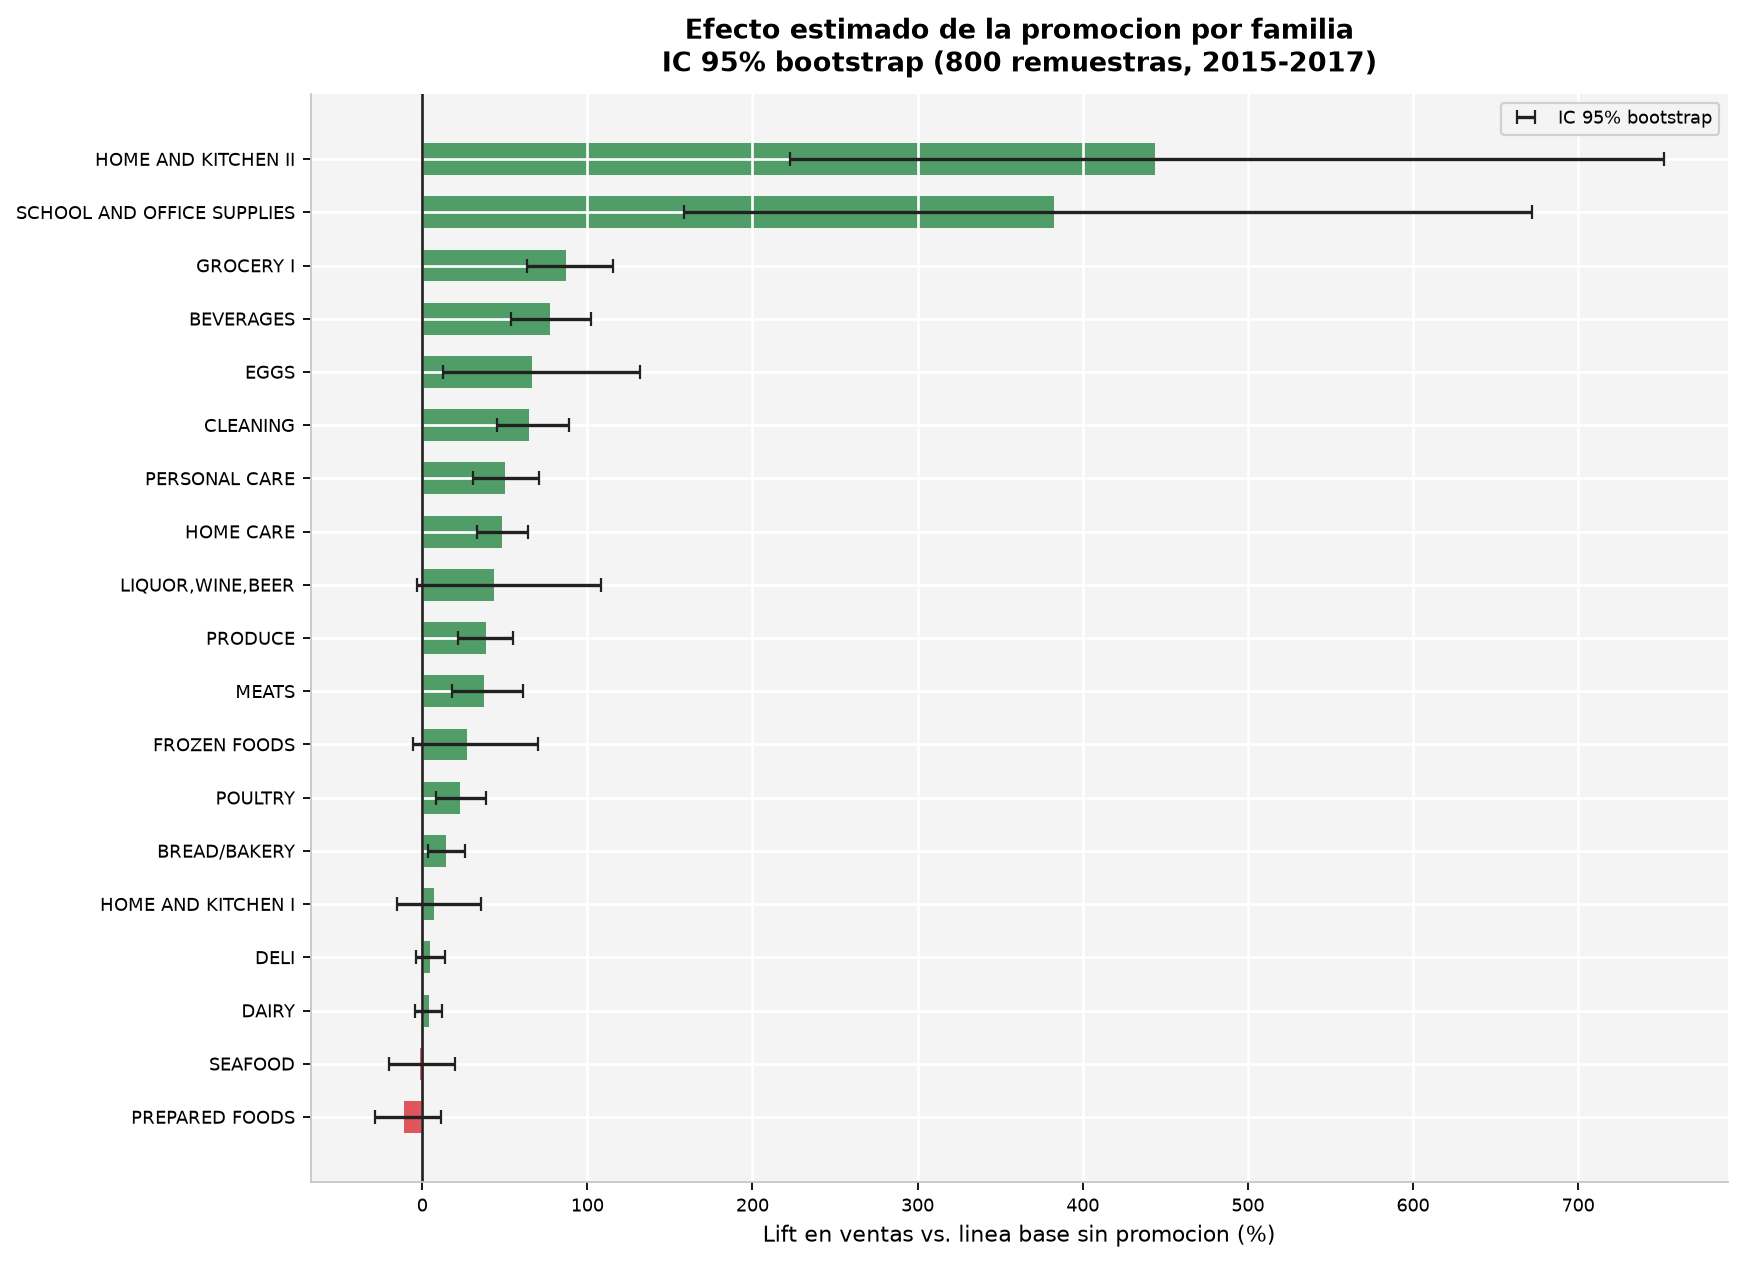

Familias con efecto estadisticamente != 0: 12/19
                   familia  lift  ci_lo  ci_hi
              BREAD/BAKERY 0.141  0.035  0.261
                   POULTRY 0.226  0.085  0.386
                     MEATS 0.376  0.179  0.608
                   PRODUCE 0.385  0.218  0.549
                 HOME CARE 0.481  0.333  0.642
             PERSONAL CARE 0.499  0.306  0.710
                  CLEANING 0.646  0.451  0.887
                      EGGS 0.664  0.125  1.321
                 BEVERAGES 0.772  0.536  1.020
                 GROCERY I 0.871  0.636  1.154
SCHOOL AND OFFICE SUPPLIES 3.827  1.586  6.719
       HOME AND KITCHEN II 4.435  2.224  7.518


In [15]:
# 6.1 Bootstrap CI por familia
promo_data = con.execute(
    "SELECT i.family, s.unit_sales, (s.onpromotion = 'True') AS en_promo "
    "FROM sales s JOIN items i USING(item_nbr) "
    "WHERE s.unit_sales > 0 AND s.onpromotion IS NOT NULL "
    "AND s.date >= '2015-01-01' AND s.id % 250 = 0 "
    "ORDER BY s.id").df()
promo_data["en_promo"] = promo_data["en_promo"].astype(bool)

rng = np.random.default_rng(seed=314)
results = []
for fam, grp in promo_data.groupby("family"):
    pv = grp[grp["en_promo"]]["unit_sales"].values
    bv = grp[~grp["en_promo"]]["unit_sales"].values
    if len(pv) < 50 or len(bv) < 50:
        continue
    boots = []
    for _ in range(800):
        p_mean = rng.choice(pv, size=min(len(pv), 2000), replace=True).mean()
        b_mean = rng.choice(bv, size=min(len(bv), 2000), replace=True).mean()
        boots.append((p_mean - b_mean) / b_mean if b_mean > 0 else np.nan)
    boots = [x for x in boots if not np.isnan(x)]
    if len(boots) < 100:
        continue
    boots = np.array(boots)
    results.append({"familia": fam, "lift": np.mean(boots),
                    "ci_lo": np.percentile(boots, 2.5),
                    "ci_hi": np.percentile(boots, 97.5), "n": len(pv)})

df_lift = pd.DataFrame(results).sort_values("lift")

fig, ax = plt.subplots(figsize=(11, 8))
y = range(len(df_lift))
cols_bar = [PAL["green"] if v > 0 else PAL["red"] for v in df_lift["lift"]]
ax.barh(y, df_lift["lift"] * 100, color=cols_bar, alpha=0.75, height=0.6)
ax.errorbar(df_lift["lift"] * 100, y,
            xerr=[(df_lift["lift"] - df_lift["ci_lo"]) * 100,
                  (df_lift["ci_hi"] - df_lift["lift"]) * 100],
            fmt="none", color=PAL["ink"], capsize=3, lw=1.5, label="IC 95% bootstrap")
ax.axvline(0, color=PAL["ink"], lw=1.2)
ax.set_yticks(y); ax.set_yticklabels(df_lift["familia"], fontsize=8)
ax.set_xlabel("Lift en ventas vs. linea base sin promocion (%)")
ax.set_title("Efecto estimado de la promocion por familia\nIC 95% bootstrap (800 remuestras, 2015-2017)")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_bootstrap_lift.png", bbox_inches="tight")
plt.show()

sig = df_lift[(df_lift["ci_lo"] > 0) | (df_lift["ci_hi"] < 0)]
print(f"Familias con efecto estadisticamente != 0: {len(sig)}/{len(df_lift)}")
print(sig[["familia","lift","ci_lo","ci_hi"]].round(3).to_string(index=False))


### Interpretación del efecto promocional

Las barras del gráfico de lift, verdes cuando el efecto es positivo y rojas cuando es
negativo, con sus respectivos intervalos de confianza al 95%, muestran que 12 de las 19
familias de productos tienen un efecto promocional estadísticamente distinguible de cero.

HOME AND KITCHEN II, con un lift aproximado de 443%, y SCHOOL AND OFFICE SUPPLIES, con un lift
aproximado de 383%, presentan los efectos más grandes. Estos valores extremos corresponden a 
categorías con bajo volumen base, donde
incluso incrementos absolutos pequeños producen porcentajes elevados. Las familias de mayor
volumen, GROCERY I con un lift aproximado de 87% y BEVERAGES con un lift aproximado de 77%,
muestran efectos más moderados pero económicamente significativos dado que representan la
mayor proporción de ventas totales. Siete familias,
entre ellas DAIRY y FROZEN FOODS, muestran intervalos de confianza que cruzan cero, lo que
indica que el efecto promocional no es distinguible del ruido muestral en estos casos.

Estos estimadores son observacionales. El lift positivo podría reflejar en parte un sesgo de
selección, si la tienda promociona productos que ya tienen alta rotación, en lugar de un
efecto causal puro de la promoción sobre las ventas.

## 7. Señales Macroeconómicas de Ecuador

Una correlación de Pearson entre dos series temporales que comparten una tendencia común
produce un coeficiente espuriamente inflado, un fenómeno documentado por Granger y Newbold
(1974) como spurious regression. Esta sección aborda el problema en dos niveles, según la
frecuencia real de cada fuente de datos.

El precio del petróleo WTI está disponible a frecuencia diaria y se agrega a nivel mensual, lo
que permite un análisis riguroso de la relación de corto plazo con las ventas una vez removida
la tendencia. El petróleo es la señal macroeconómica más relevante para Ecuador, ya que el
presupuesto público y el ciclo económico del país dependen fuertemente de él.

La inflación y las remesas provienen del Banco Mundial y solo están disponibles a frecuencia
anual. Ecuador es una economía dolarizada desde el año 2000, por lo que no existe un tipo de
cambio propio; las remesas son una de las principales fuentes de ingreso de los hogares. Al
tratarse de series anuales, estas dos variables se analizan a nivel anual y de forma
descriptiva, sin inferencia estadística.

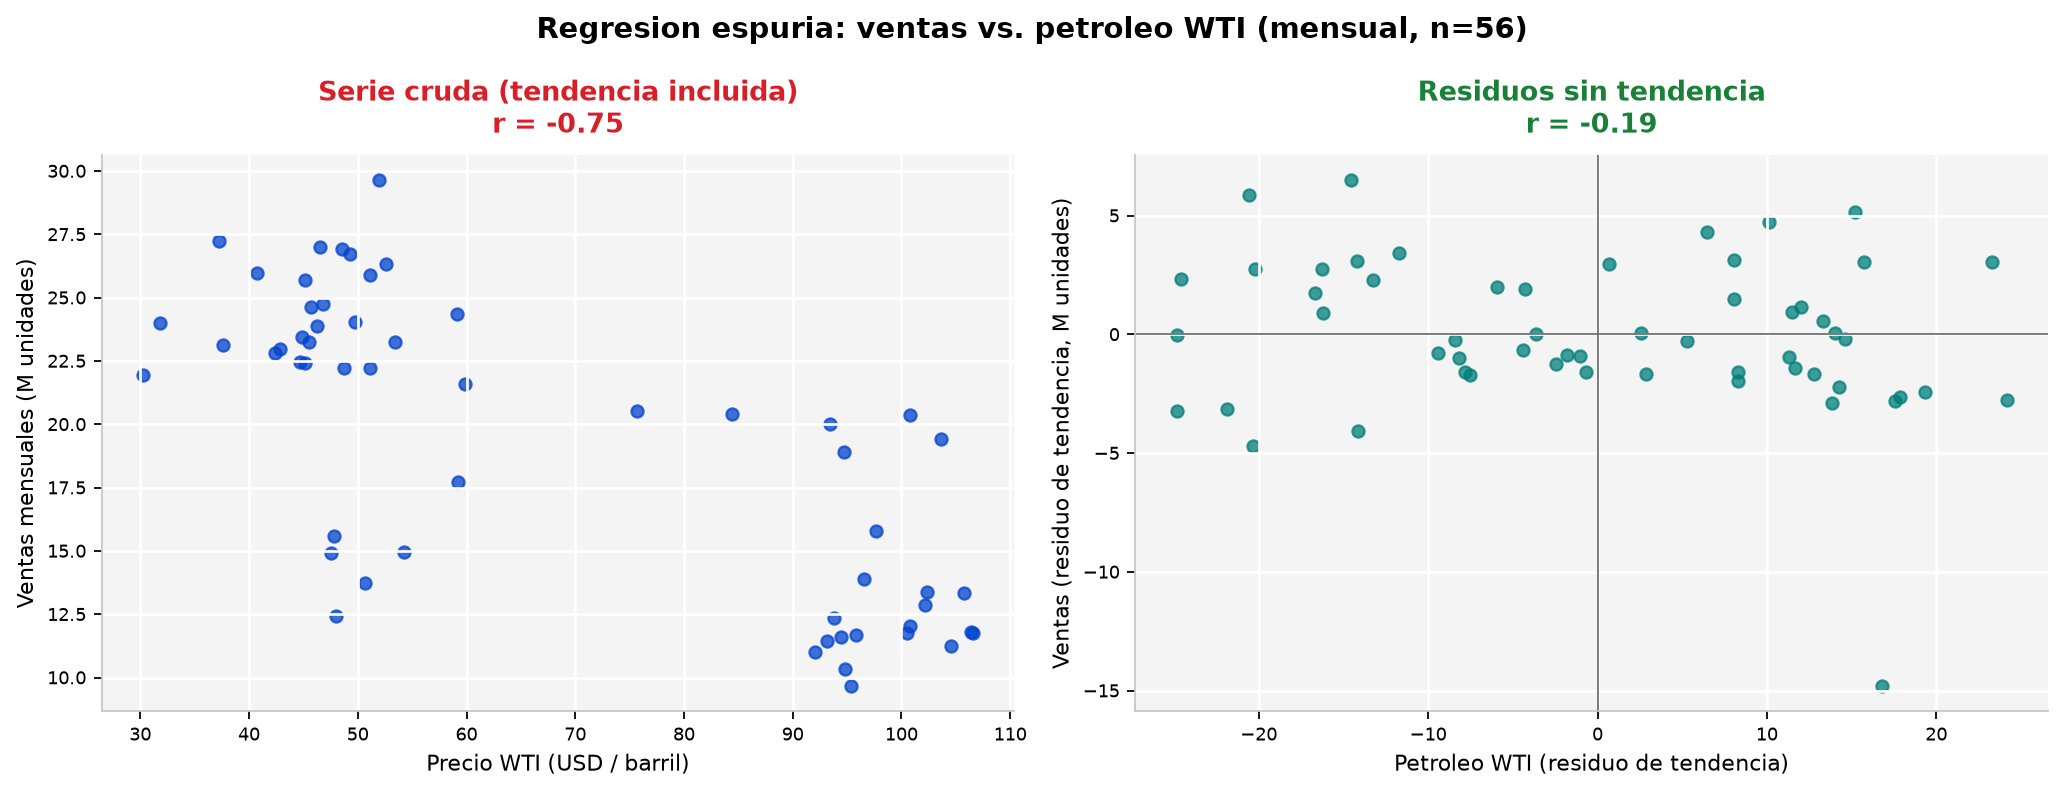

r(ventas, petroleo) crudo    : -0.750
r(ventas, petroleo) corregido: -0.185
La tendencia comun infla el coeficiente en 0.564 puntos


In [16]:
# 7.1 Petroleo WTI (mensual): correlacion espuria vs. corregida por tendencia
def detrend_ols(series):
    t    = np.arange(len(series))
    coef = np.polyfit(t, series.values, 1)
    return series - np.polyval(coef, t)

ventas_dt = detrend_ols(macro["ventas_totales"])
oil_dt    = detrend_ols(macro["oil_price"])

r_raw = np.corrcoef(macro["ventas_totales"], macro["oil_price"])[0, 1]
r_dt  = np.corrcoef(ventas_dt, oil_dt)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(macro["oil_price"], macro["ventas_totales"] / 1e6,
                s=30, alpha=0.75, color=PAL["blue"])
axes[0].set_title(f"Serie cruda (tendencia incluida)\nr = {r_raw:.2f}", color=PAL["red"])
axes[0].set_xlabel("Precio WTI (USD / barril)")
axes[0].set_ylabel("Ventas mensuales (M unidades)")

axes[1].scatter(oil_dt, ventas_dt / 1e6, s=30, alpha=0.75, color=PAL["teal"])
axes[1].axhline(0, color=PAL["gray"], lw=0.8)
axes[1].axvline(0, color=PAL["gray"], lw=0.8)
axes[1].set_title(f"Residuos sin tendencia\nr = {r_dt:.2f}", color=PAL["green"])
axes[1].set_xlabel("Petroleo WTI (residuo de tendencia)")
axes[1].set_ylabel("Ventas (residuo de tendencia, M unidades)")

plt.suptitle("Regresion espuria: ventas vs. petroleo WTI (mensual, n=56)", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_macro_corr.png", bbox_inches="tight")
plt.show()

print(f"r(ventas, petroleo) crudo    : {r_raw:.3f}")
print(f"r(ventas, petroleo) corregido: {r_dt:.3f}")
print(f"La tendencia comun infla el coeficiente en {abs(r_raw - r_dt):.3f} puntos")

### Interpretación: regresión espuria entre ventas y petróleo

El panel izquierdo muestra la relación cruda entre las ventas mensuales y el precio del
petróleo, con una correlación de $r = -0.75$ que sugeriría un vínculo fuerte e inverso. Buena
parte de esa asociación proviene de que ambas series tienen tendencias opuestas durante el
período: las ventas crecieron por la expansión de la red de tiendas mientras el precio del
petróleo cayó tras 2014.

El panel derecho muestra la relación entre los residuos de ambas series una vez removida la
tendencia lineal. La correlación corregida cae a $r = -0.19$, de modo que alrededor de 0.56
puntos del coeficiente original eran un artefacto de la tendencia compartida. La relación de
corto plazo se mantiene negativa, consistente con la teoría económica, pero su magnitud es
modesta y opera de forma indirecta a través del presupuesto público, el empleo y el poder
adquisitivo.

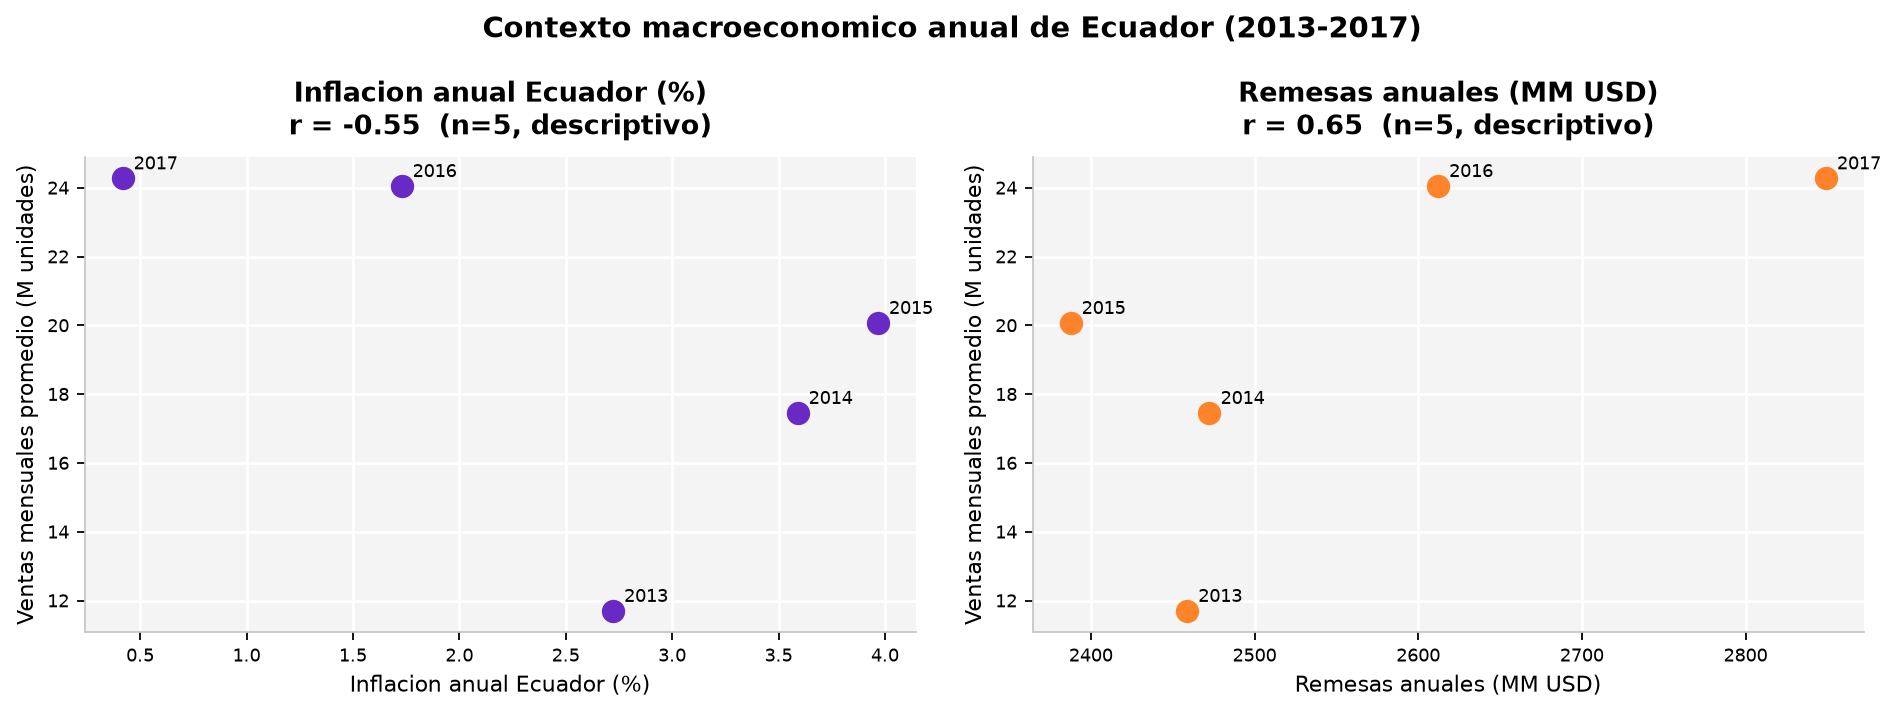

Correlaciones ANUALES (n=5, descriptivas, dominadas por tendencia comun):
  r(ventas_prom anual, IPC) = -0.551
  r(ventas_prom anual, Remesas) = 0.652


In [17]:
# 7.2 Contexto macroeconomico anual: IPC y remesas de Ecuador (World Bank)
# IPC y remesas solo estan disponibles a frecuencia ANUAL. Se analizan a ese
# nivel (n=5) y de forma descriptiva; con tan pocos puntos no cabe inferencia.
anual = (macro.assign(year=macro["fecha"].dt.year)
              .groupby("year")
              .agg(ventas_prom=("ventas_totales", "mean"),
                   ipc_pct=("ipc_var_pct", "first"),
                   remesas_mm=("remesas_usd_mm", "first"))
              .reset_index())
# Recuperar la escala anual desde el equivalente mensual guardado en el CSV
anual["ipc_pct"]    *= 12    # tasa de inflacion anual (%)
anual["remesas_mm"] *= 12    # remesas anuales (MM USD)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, lab, color in [
    (axes[0], "ipc_pct",    "Inflacion anual Ecuador (%)", PAL["purple"]),
    (axes[1], "remesas_mm", "Remesas anuales (MM USD)",    PAL["orange"]),
]:
    ax.scatter(anual[col], anual["ventas_prom"] / 1e6, s=90, color=color, zorder=5)
    for _, row in anual.iterrows():
        ax.annotate(int(row["year"]), (row[col], row["ventas_prom"] / 1e6),
                    fontsize=8, xytext=(5, 4), textcoords="offset points")
    r = np.corrcoef(anual[col], anual["ventas_prom"])[0, 1]
    ax.set_title(f"{lab}\nr = {r:.2f}  (n={len(anual)}, descriptivo)")
    ax.set_xlabel(lab)
    ax.set_ylabel("Ventas mensuales promedio (M unidades)")

plt.suptitle("Contexto macroeconomico anual de Ecuador (2013-2017)", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_macro_anual.png", bbox_inches="tight")
plt.show()

print(f"Correlaciones ANUALES (n={len(anual)}, descriptivas, dominadas por tendencia comun):")
for col, lab in [("ipc_pct", "IPC"), ("remesas_mm", "Remesas")]:
    r = np.corrcoef(anual[col], anual["ventas_prom"])[0, 1]
    print(f"  r(ventas_prom anual, {lab}) = {r:.3f}")

### Interpretación del contexto macroeconómico anual

Con solo cinco observaciones anuales, estas correlaciones son descriptivas y no admiten
inferencia estadística. Todas están dominadas por la tendencia común del período: las ventas
crecieron de forma sostenida por la expansión de tiendas, de manera que cualquier variable que
haya subido o bajado de forma monótona entre 2013 y 2017 exhibirá una correlación alta con las
ventas sin que ello implique una relación causal.

Con esa salvedad, la inflación anual presenta una correlación negativa con las ventas promedio,
en torno a $r \approx -0.55$: los años de menor inflación coinciden con mayores volúmenes,
aunque el efecto se confunde con la expansión de la red. Las remesas muestran una correlación
positiva, en torno a $r \approx 0.65$, consistente con su rol como ingreso complementario de
los hogares ecuatorianos, pero igualmente condicionada por la tendencia. 

## 8. Selección Cuantitativa de Subconjuntos para Modelado Causal

No todos los pares tienda-familia son candidatos apropiados para el modelado causal. Un
subconjunto válido debe satisfacer criterios mínimos de cobertura temporal, volumen, actividad
y estabilidad, de modo que los estimadores tengan suficiente potencia estadística y los
patrones detectados sean genuinos.

Los criterios de elegibilidad exigen al menos 1,400 días con datos, una cobertura mínima del
85% del período 2013-2017; un promedio diario de al menos 5 unidades vendidas; al menos 70%
de días con ventas positivas; y diversidad de familia de producto y tipo de tienda. El score
compuesto pondera logarítmicamente el volumen total, penaliza por coeficiente de variación
elevado y bonifica por porcentaje de días activos.

In [18]:
# 8.1 Score compuesto para seleccion
candidatos = con.execute(
    "WITH base AS ("
    "  SELECT s.store_nbr, i.family, "
    "    COUNT(DISTINCT s.date) dias_dato, "
    "    COUNT(DISTINCT s.date) FILTER(WHERE s.unit_sales>0) dias_venta, "
    "    ROUND(AVG(s.unit_sales) FILTER(WHERE s.unit_sales>0),2) avg_s, "
    "    ROUND(STDDEV(s.unit_sales) FILTER(WHERE s.unit_sales>0),2) sd_s, "
    "    ROUND(SUM(s.unit_sales),0) total "
    "  FROM sales s JOIN items i USING(item_nbr) WHERE s.unit_sales>=0 "
    "  GROUP BY 1,2 "
    ") "
    "SELECT *, ROUND(sd_s/NULLIF(avg_s,0),2) cv, "
    "  ROUND(100.0*dias_venta/dias_dato,1) pct_activo "
    "FROM base "
    "WHERE dias_dato>=1400 AND avg_s>=5 AND dias_venta*1.0/dias_dato>=0.70 "
    "ORDER BY total DESC LIMIT 30").df()

candidatos = candidatos.merge(
    stores[["store_nbr","type","cluster","city"]], on="store_nbr", how="left")
candidatos["score"] = (
    np.log1p(candidatos["total"])
    * candidatos["pct_activo"] / 100
    / (1 + candidatos["cv"] / 10))
candidatos = candidatos.sort_values(by="score", ascending=False)
print(f"Candidatos elegibles: {len(candidatos)}")
candidatos[["store_nbr","family","type","cluster","avg_s","pct_activo","cv","score"]].head(10)


Candidatos elegibles: 30


,store_nbr,family,type,cluster,avg_s,pct_activo,cv,score
2,47,GROCERY I,A,14,12.93,100.0,1.55,14.335336
5,3,GROCERY I,D,8,11.07,100.0,1.51,14.229627
14,50,GROCERY I,A,14,9.03,100.0,1.48,14.050732
6,48,GROCERY I,A,14,11.34,100.0,1.74,13.941559
12,44,PRODUCE,A,5,50.26,100.0,1.61,13.938487
21,6,GROCERY I,D,13,7.20,100.0,1.40,13.921530
16,3,PRODUCE,D,8,42.87,100.0,1.48,13.910126
17,51,GROCERY I,A,17,8.10,100.0,1.53,13.810762
19,8,GROCERY I,D,8,7.09,100.0,1.51,13.799897
3,46,GROCERY I,A,14,12.29,100.0,1.95,13.789891


### Interpretación de la selección de candidatos

De las 1,782 combinaciones posibles entre 54 tiendas y 33 familias, 30 subconjuntos satisfacen
todos los criterios de elegibilidad. La tabla presenta los 10 primeros ordenados por el score
compuesto.

Las familias GROCERY I y BEVERAGES dominan la lista, consistente con el análisis de Pareto de
la Sección 4.2, y las tiendas tipo A, de gran formato, están sobrerrepresentadas, lo que
refleja su mayor volumen y estabilidad. El coeficiente de variación de los candidatos oscila
entre 1.5 y 2.7, una dispersión moderada y manejable para modelos de series temporales, y
todos los candidatos del top 10 registran el 100% de días activos, lo que garantiza
continuidad en la serie temporal.

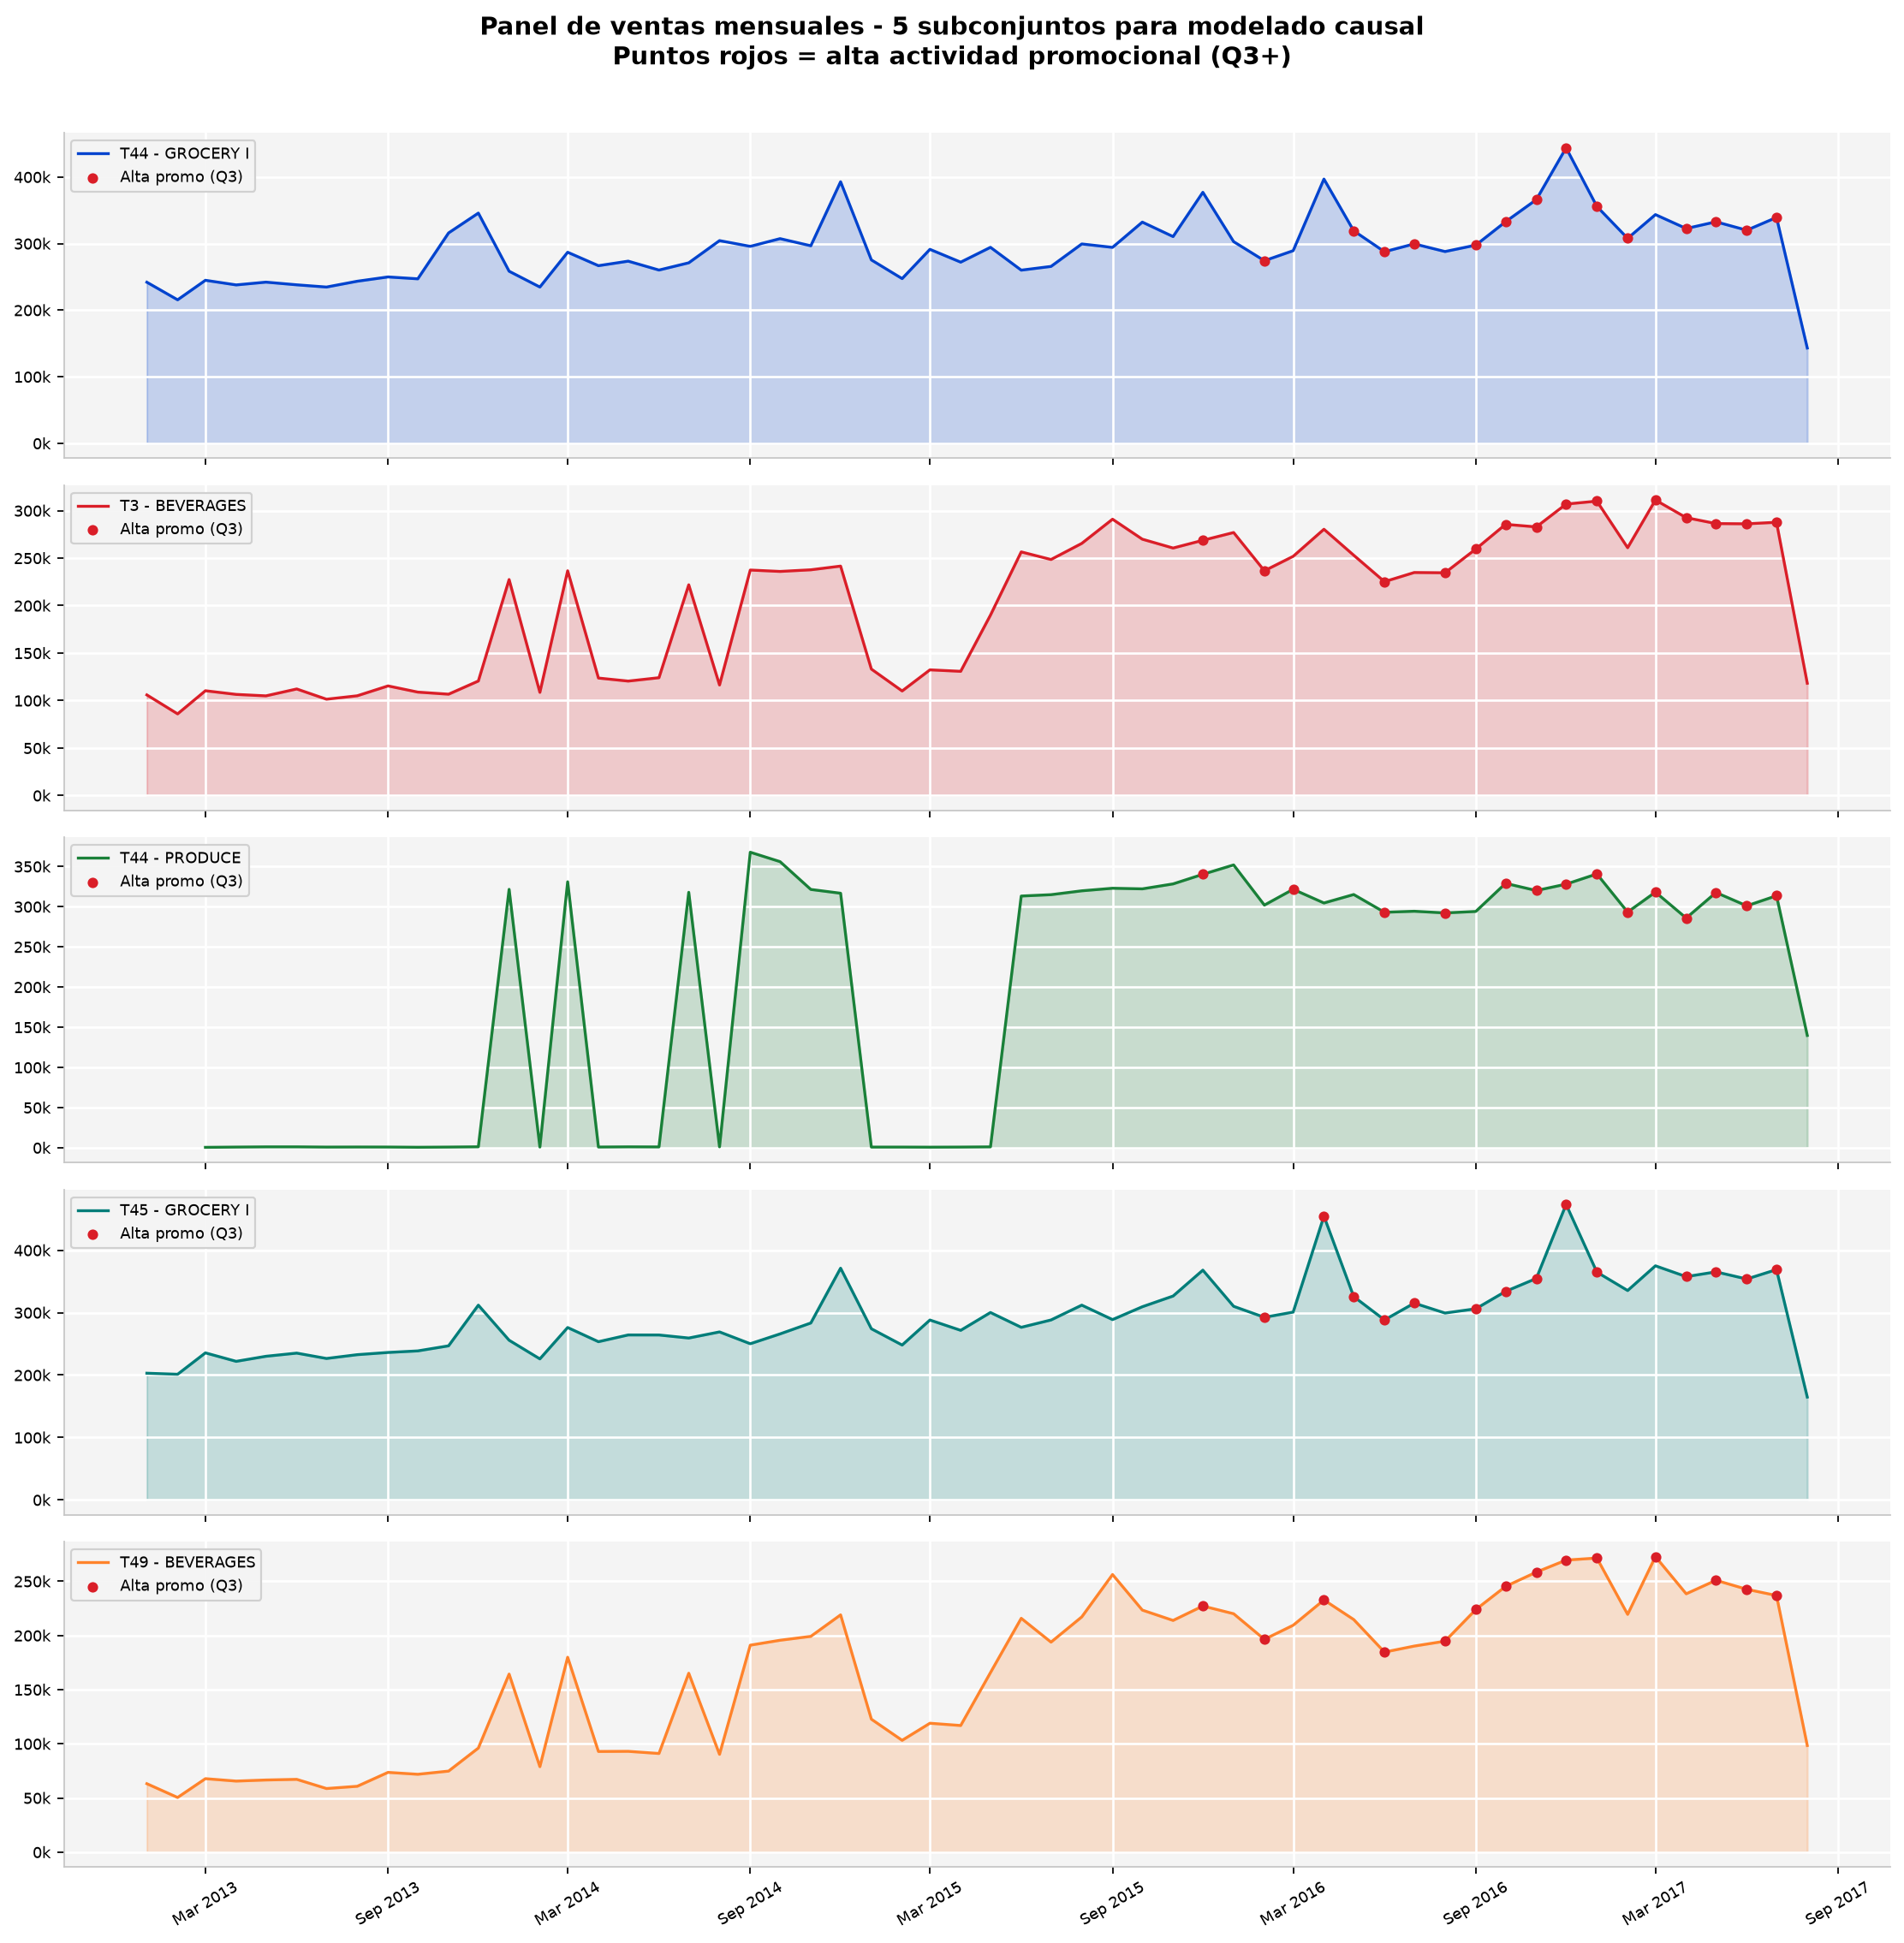

In [19]:
# 8.2 Panel de series de los 5 subconjuntos seleccionados
SELECCIONADOS = [(44,"GROCERY I"),(3,"BEVERAGES"),(44,"PRODUCE"),(45,"GROCERY I"),(49,"BEVERAGES")]
filtro = " OR ".join(f"(s.store_nbr={sn} AND i.family='{fam}')" for sn, fam in SELECCIONADOS)

df_sub = con.execute(
    f"SELECT s.store_nbr, i.family, DATE_TRUNC('month', s.date) mes, "
    f"ROUND(SUM(s.unit_sales),0) ventas, "
    f"COUNT(*) FILTER(WHERE s.onpromotion='True') n_promo "
    f"FROM sales s JOIN items i USING(item_nbr) "
    f"WHERE s.unit_sales>=0 AND ({filtro}) "
    f"GROUP BY 1,2,3 ORDER BY 1,2,3").df()
df_sub["mes"]   = pd.to_datetime(df_sub["mes"])
df_sub["label"] = "T" + df_sub["store_nbr"].astype(str) + " - " + df_sub["family"]

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ax, (sn, fam) in zip(axes, SELECCIONADOS):
    lbl = f"T{sn} - {fam}"
    d   = df_sub[df_sub["label"] == lbl]
    col = SUBSET_PAL.get(lbl, PAL["gray"])
    ax.fill_between(d["mes"], d["ventas"], alpha=0.2, color=col)
    ax.plot(d["mes"], d["ventas"], color=col, lw=1.5, label=lbl)
    promo_hi = d[d["n_promo"] > d["n_promo"].quantile(0.75)]
    ax.scatter(promo_hi["mes"], promo_hi["ventas"],
               s=20, color=PAL["red"], zorder=5, label="Alta promo (Q3)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k"))
    ax.legend(loc="upper left", fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.suptitle("Panel de ventas mensuales - 5 subconjuntos para modelado causal\n"
             "Puntos rojos = alta actividad promocional (Q3+)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "reports/fig_subsets_panel.png", bbox_inches="tight")
plt.show()


### Interpretación del panel de series seleccionadas

Los cinco subconjuntos seleccionados para el modelado causal, cada uno graficado en un color
distinto con relleno bajo la curva, muestran características complementarias. Los puntos
rojos superpuestos marcan los meses de mayor actividad promocional.

T44-GROCERY I y T45-GROCERY I son series estables con tendencia creciente suave y
estacionalidad semanal marcada; los puntos rojos de alta actividad promocional coinciden con
frecuencia con los picos de ventas.
T3-BEVERAGES presenta mayor variabilidad que las series de GROCERY I, con picos promocionales
más pronunciados, y la amplitud estacional parece crecer con el nivel de la serie, una
heteroscedasticidad multiplicativa que refuerza la necesidad de una transformación
logarítmica. T44-PRODUCE exhibe una ruptura estructural antes de 2015, donde las ventas
colapsan a cero, este colapso es un
artefacto de surtido y no de demanda, por lo que los modelos deben restringirse a datos
posteriores a 2015 para esta combinación. T49-BEVERAGES muestra un volumen menor pero un
patrón estacional claro y estable.

La diversidad de estos subconjuntos en familia, tipo de tienda, cluster y nivel de volumen
permitirá evaluar la generalización del modelo causal a través de distintos contextos
operativos.

## 9. Hallazgos Clave y Marco Causal

### Grafo Acíclico Dirigido del Sistema

El siguiente diagrama representa las relaciones causales hipotéticas entre las variables del
sistema y guía la selección de variables de control y la interpretación de los efectos
estimados en las secciones anteriores. Los nodos están organizados en tres capas causales:
exógenas, intermedias y endógenas.

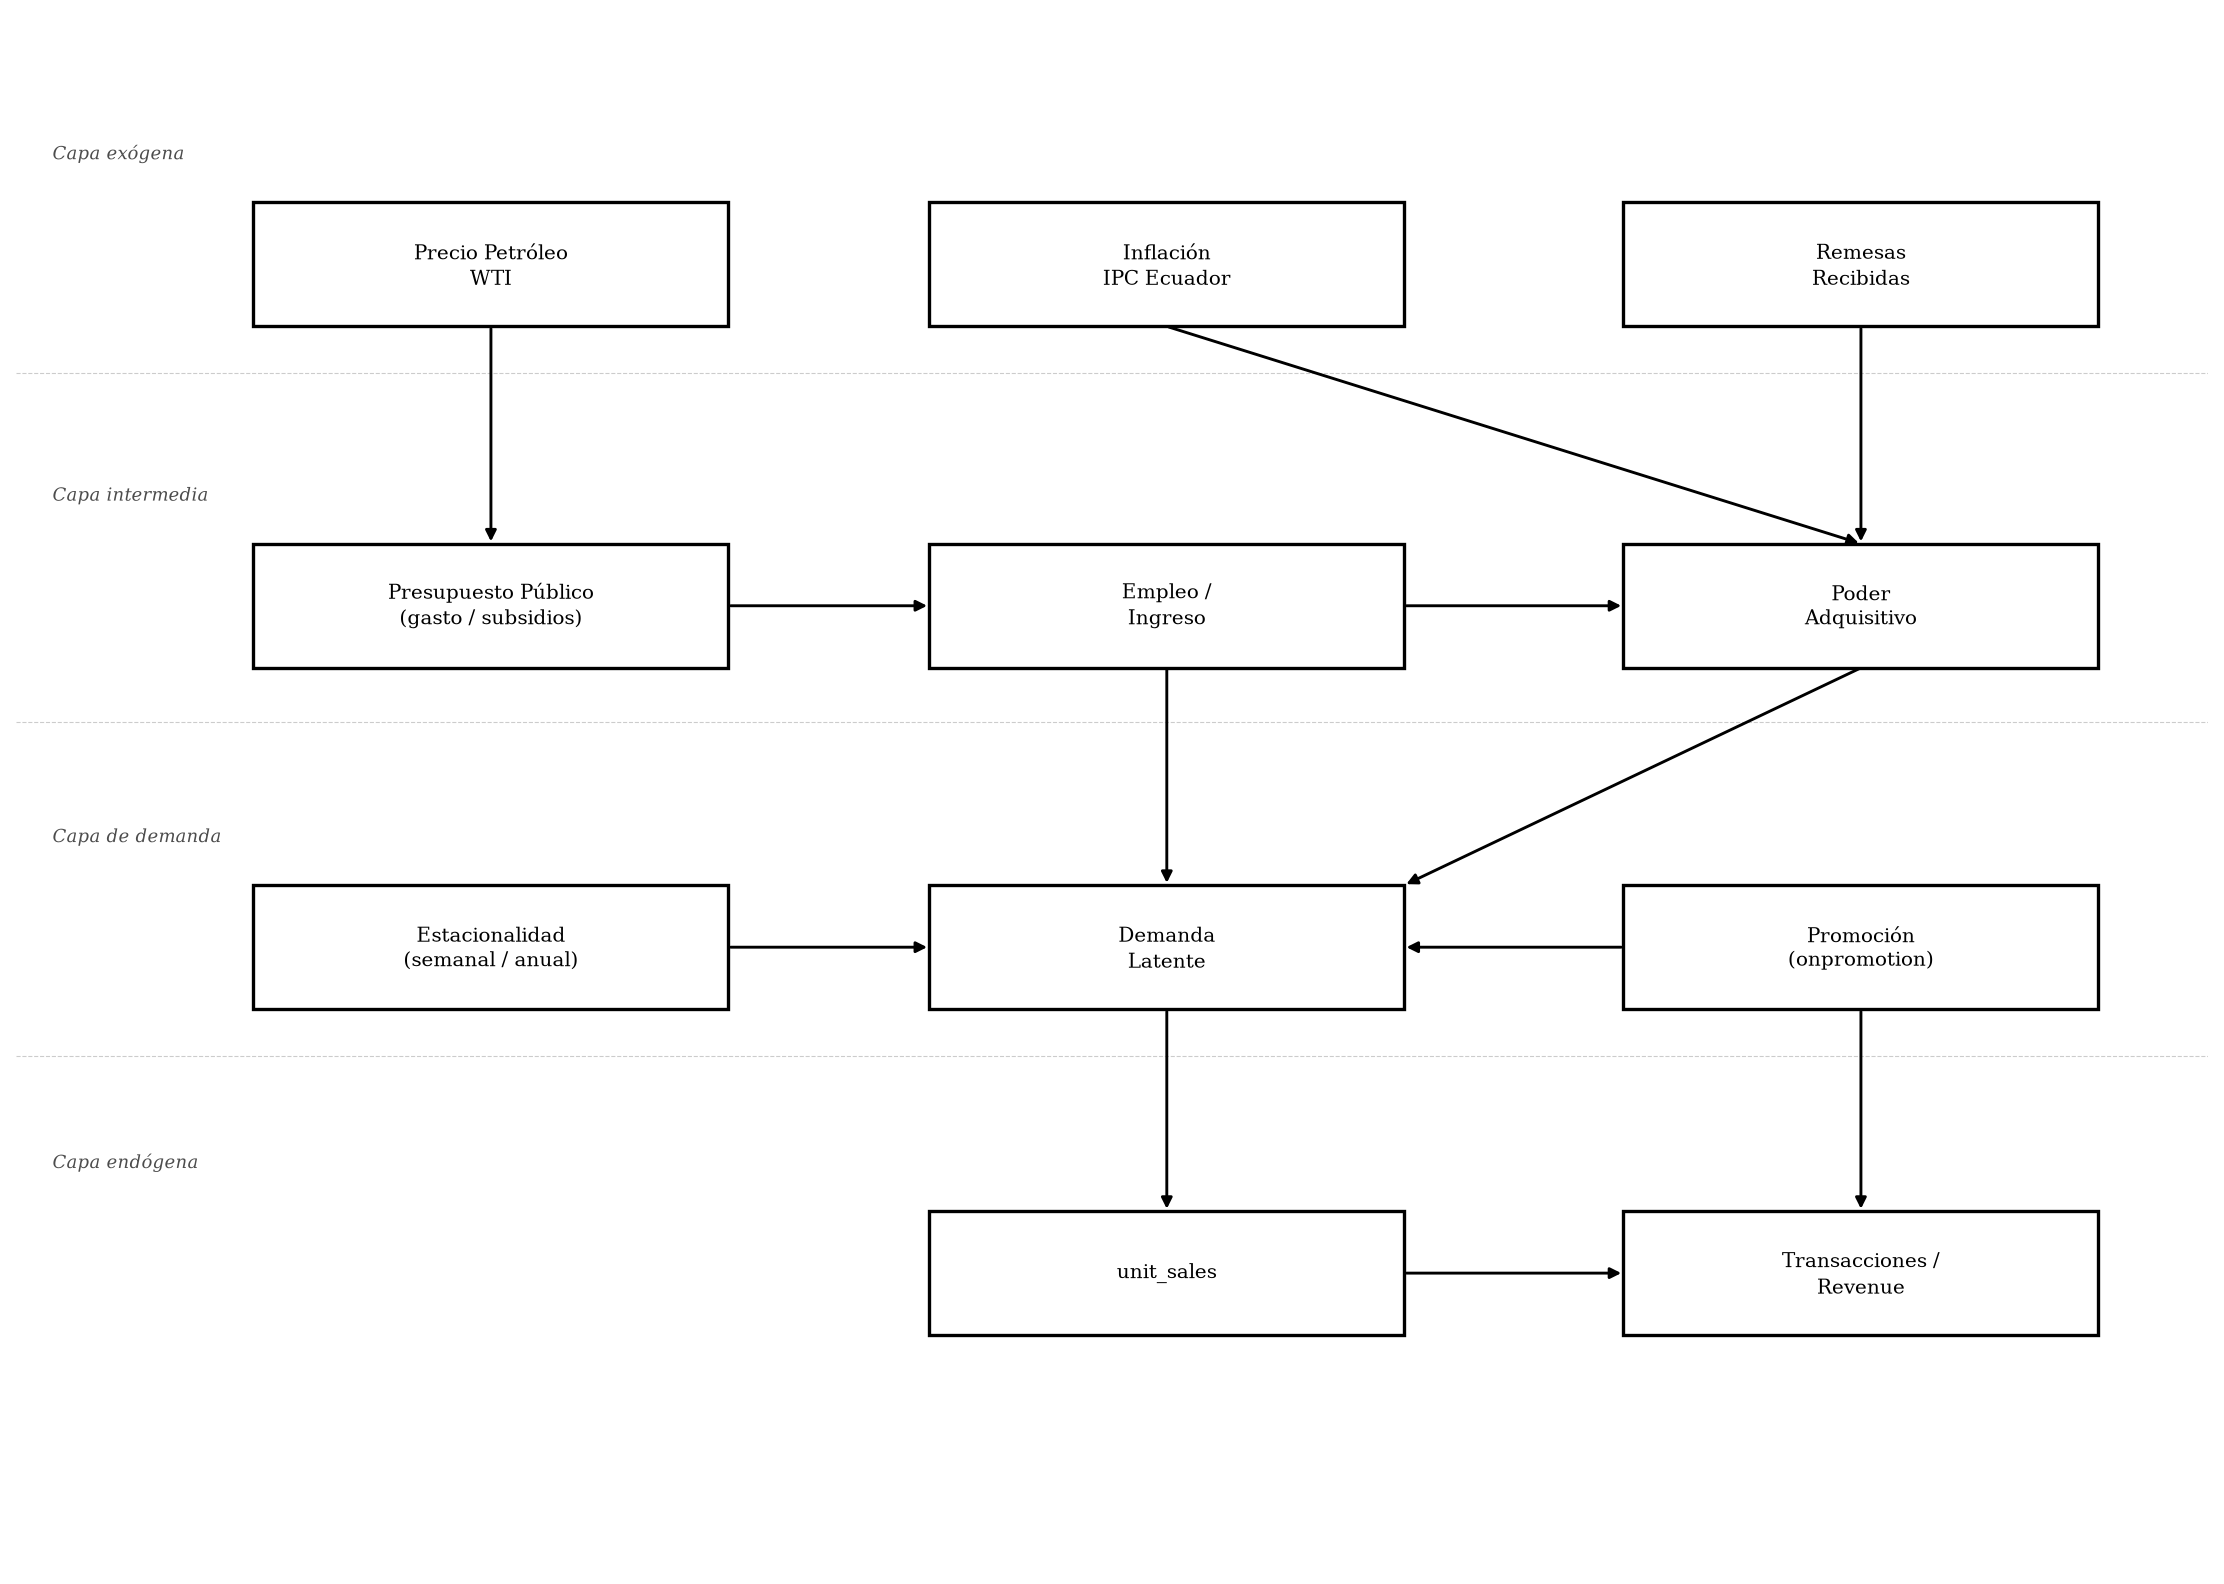

In [22]:
#  Grafo Acíclico Dirigido (DAG) del sistema causal 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(-1, 11)
ax.set_ylim(-0.5, 9.5)
ax.axis('off')
fig.patch.set_facecolor('white')

#  Nodos: (x, y, w, h, label)
nodes = [
    # Capa exógena (top)
    (0.3,  7.5, 2.6, 0.8, "Precio Petróleo\nWTI"),
    (4.0,  7.5, 2.6, 0.8, "Inflación\nIPC Ecuador"),
    (7.8,  7.5, 2.6, 0.8, "Remesas\nRecibidas"),
    # Capa intermedia
    (0.3,  5.3, 2.6, 0.8, "Presupuesto Público\n(gasto / subsidios)"),
    (4.0,  5.3, 2.6, 0.8, "Empleo /\nIngreso"),
    (7.8,  5.3, 2.6, 0.8, "Poder\nAdquisitivo"),
    # Capa de demanda
    (0.3,  3.1, 2.6, 0.8, "Estacionalidad\n(semanal / anual)"),
    (4.0,  3.1, 2.6, 0.8, "Demanda\nLatente"),
    (7.8,  3.1, 2.6, 0.8, "Promoción\n(onpromotion)"),
    # Capa endógena (bottom)
    (4.0,  1.0, 2.6, 0.8, "unit_sales"),
    (7.8,  1.0, 2.6, 0.8, "Transacciones /\nRevenue"),
]

drawn = {}
for (x, y, w, h, label) in nodes:
    rect = plt.Rectangle(
        (x, y), w, h,
        facecolor='white', edgecolor='black', linewidth=1.5,
        zorder=3
    )
    ax.add_patch(rect)
    ax.text(
        x + w/2, y + h/2, label,
        ha='center', va='center', fontsize=9,
        fontweight='normal', color='black', zorder=4,
        fontfamily='serif', linespacing=1.3
    )
    drawn[label.replace("\n", " ")] = (x, y, w, h)

# Flechas rectas 
def arrow_v(src, dst):
    """Vertical arrow: bottom-center of src to top-center of dst."""
    sx, sy, sw, sh = drawn[src]
    dx, dy, dw, dh = drawn[dst]
    ax.annotate('', xy=(dx + dw/2, dy + dh), xytext=(sx + sw/2, sy),
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.3,
                                shrinkA=1, shrinkB=1))

def arrow_h(src, dst):
    """Horizontal arrow: right of src to left of dst."""
    sx, sy, sw, sh = drawn[src]
    dx, dy, dw, dh = drawn[dst]
    ax.annotate('', xy=(dx, dy + dh/2), xytext=(sx + sw, sy + sh/2),
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.3,
                                shrinkA=1, shrinkB=1))

def arrow_diag(src, dst, src_side='bottom_right', dst_side='top_left'):
    """Diagonal arrow with configurable connection points."""
    sx, sy, sw, sh = drawn[src]
    dx, dy, dw, dh = drawn[dst]
    points = {
        'bottom_center': (sx + sw/2, sy),
        'bottom_right':  (sx + sw, sy),
        'bottom_left':   (sx, sy),
        'left_center':   (sx, sy + sh/2),
        'right_center':  (sx + sw, sy + sh/2),
    }
    # src points use sx,sy; dst points use dx,dy — recalc dst
    dst_points = {
        'top_center':    (dx + dw/2, dy + dh),
        'top_left':      (dx, dy + dh),
        'top_right':     (dx + dw, dy + dh),
        'left_center':   (dx, dy + dh/2),
        'right_center':  (dx + dw, dy + dh/2),
        'bottom_center': (dx + dw/2, dy),
    }
    src_pt = points.get(src_side, (sx + sw/2, sy))
    dst_pt = dst_points.get(dst_side, (dx + dw/2, dy + dh))
    ax.annotate('', xy=dst_pt, xytext=src_pt,
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.3,
                                shrinkA=1, shrinkB=1))

# Exógena -> Intermedia
arrow_v("Precio Petróleo WTI", "Presupuesto Público (gasto / subsidios)")
arrow_diag("Inflación IPC Ecuador", "Poder Adquisitivo",
           src_side='bottom_center', dst_side='top_center')
arrow_diag("Remesas Recibidas", "Poder Adquisitivo",
           src_side='bottom_center', dst_side='top_center')

# Intermedia -> Intermedia
arrow_h("Presupuesto Público (gasto / subsidios)", "Empleo / Ingreso")
arrow_h("Empleo / Ingreso", "Poder Adquisitivo")

# Intermedia -> Demanda
arrow_v("Empleo / Ingreso", "Demanda Latente")
arrow_diag("Poder Adquisitivo", "Demanda Latente",
           src_side='bottom_center', dst_side='top_right')
arrow_h("Estacionalidad (semanal / anual)", "Demanda Latente")
# Promoción -> Demanda (center to center, horizontal)
arrow_diag("Promoción (onpromotion)", "Demanda Latente",
           src_side='left_center', dst_side='right_center')

# Demanda -> Endógena
arrow_v("Demanda Latente", "unit_sales")
# Promoción -> unit_sales (vertical, straight down)
arrow_v("Promoción (onpromotion)", "Transacciones / Revenue")
arrow_h("unit_sales", "Transacciones / Revenue")

# Etiquetas de capa (formal, serif) 
for ypos, lbl in [(8.55, 'Capa exógena'),
                   (6.35, 'Capa intermedia'),
                   (4.15, 'Capa de demanda'),
                   (2.05, 'Capa endógena')]:
    ax.text(-0.8, ypos, lbl, fontsize=8, color='black', fontfamily='serif',
            fontstyle='italic', va='bottom', alpha=0.7)

# Líneas divisorias punteadas
for y_line in [7.2, 4.95, 2.8]:
    ax.axhline(y=y_line, color='gray', linewidth=0.5, linestyle='--', alpha=0.4)

ax.set_title(
    '',
    fontsize=13, fontweight='bold', pad=20,
    fontfamily='serif', color='black'
)

plt.tight_layout()
plt.show()

### Cinco hallazgos que definen el diseño del modelo

1. *onpromotion* es MNAR y su imputación introduce sesgo causal. Los 21.6 millones de valores
   faltantes en *onpromotion* no son ruido aleatorio: corresponden al período anterior a julio
   de 2014, cuando el sistema de captura de promociones no existía. Bajo el marco de Little y
   Rubin, esto constituye un mecanismo MNAR, ya que la probabilidad de observar el dato
   depende de la infraestructura del sistema y no de las variables observadas. La estrategia
   correcta es crear un indicador de régimen, *promo_tracked*, y no imputar como *False*.

2. La tendencia común infla las correlaciones macroeconómicas. La correlación cruda entre
   ventas y precio del petróleo es $r = -0.75$, pero al eliminar la tendencia temporal
   compartida el coeficiente corregido se reduce a $r \approx -0.19$. Esto significa que 0.56
   puntos de la correlación original eran espurios, producidos por tendencias seculares
   opuestas entre ambas series. El petróleo, disponible a frecuencia mensual, es la
   señal macro más relevante para Ecuador y opera a través del presupuesto público y el
   empleo. La inflación y las remesas solo están disponibles a nivel anual, por lo que se
   tratan como contexto descriptivo y no como predictores cuantificados.

3. La descomposición STL confirma crecimiento real, no solo efecto macro. La tendencia
   extraída por STL muestra un crecimiento sostenido hasta mediados de 2016, coincidiendo con
   la expansión de la red de tiendas de Corporación Favorita. La estacionalidad semanal
   explica el 47% de la varianza total, una proporción alta que indica que un modelo sin
   componente semanal tendrá errores sistemáticos sustanciales.

4. T44-PRODUCE presenta ruptura estructural antes de 2015. Los colapsos a cero observados
   antes de 2015 en la combinación Tienda 44 / PRODUCE son artefactos de surtido, pues la
   categoría no se vendía en esa tienda, y no caídas genuinas de demanda. Un modelo que
   utilice datos previos a 2015 de este subconjunto detectará un quiebre de nivel espurio que
   sesgaría las estimaciones de tendencia.

5. El sábado concentra aproximadamente 30% más ventas que el promedio semanal. Los heatmaps
   de calendario revelan un patrón semanal consistente a lo largo de los cinco años
   analizados: los sábados son sistemáticamente los días de mayor volumen. Este hallazgo,
   combinado con el pico anual de diciembre, implica que un modelo sin variables de día de la
   semana y mes del año tendrá errores de predicción estructurales e irreducibles.

In [23]:
# Tabla resumen post-procesamiento 
from IPython.display import HTML

rows_data = [
    ("onpromotion",       "VARCHAR · 21.6M NAs (MNAR)",  "Indicador promo_tracked", "Documentado"),
    ("oil.dcoilwtico",    "43 NAs en feriados NYMEX",     "LOCF aplicado",                        "Aplicado"),
    ("unit_sales &lt; 0", "7,795 devoluciones",            "Conservar + flag is_return", "Documentado"),
    ("transactions gaps", "~8,600 días ausentes",          "Left join + holidays cross-ref",       "Pendiente"),
    ("perishable",        "BIGINT vs BOOLEAN",             "Cast a bool",             "Aplicado"),
    ("item / store FK",   "Sin restricciones en BD",       "0 huérfanos verificados",              "Verificado"),
]

rows_html = ""
for i, (campo, prob, estrat, estado) in enumerate(rows_data):
    bg = "#f7f7f7" if i % 2 == 0 else "#ffffff"
    rows_html += (
        f'<tr style="background:{bg};">'
        f'<td style="padding:8px 12px; border-bottom:1px solid #ccc; '
        f'font-family:Consolas,Liberation Mono,monospace; font-size:12px;">{campo}</td>'
        f'<td style="padding:8px 12px; border-bottom:1px solid #ccc;">{prob}</td>'
        f'<td style="padding:8px 12px; border-bottom:1px solid #ccc;">{estrat}</td>'
        f'<td style="padding:8px 12px; border-bottom:1px solid #ccc; text-align:center; '
        f'font-weight:600;">{estado}</td>'
        f'</tr>'
    )

html = (
    '<div style="margin:20px 0;">'
    '<table style="border-collapse:collapse; width:100%; '
    'font-family:Georgia,Times New Roman,serif; font-size:13px; '
    'border-top:2px solid black; border-bottom:2px solid black;">'
    '<thead>'
    '<tr style="border-bottom:1px solid black;">'
    '<th style="padding:10px 12px; text-align:left; font-size:12px; '
    'text-transform:uppercase; letter-spacing:1px; font-weight:700;">Campo</th>'
    '<th style="padding:10px 12px; text-align:left; font-size:12px; '
    'text-transform:uppercase; letter-spacing:1px; font-weight:700;">Problema detectado</th>'
    '<th style="padding:10px 12px; text-align:left; font-size:12px; '
    'text-transform:uppercase; letter-spacing:1px; font-weight:700;">Estrategia</th>'
    '<th style="padding:10px 12px; text-align:center; font-size:12px; '
    'text-transform:uppercase; letter-spacing:1px; font-weight:700;">Estado</th>'
    '</tr></thead>'
    f'<tbody>{rows_html}</tbody></table>'
    '<p style="font-size:11px; color:#555; margin-top:6px; font-family:Georgia,serif; '
    'font-style:italic;">'
    'Tabla 9.1. Resumen de calidad de datos y decisiones de procesamiento. '
    'Las estrategias documentadas se implementarán en el pipeline de feature engineering.'
    '</p></div>'
)

display(HTML(html))

con.close()
print("\nConexión cerrada. EDA avanzado completo.")

Campo,Problema detectado,Estrategia,Estado
onpromotion,VARCHAR · 21.6M NAs (MNAR),Indicador promo_tracked,Documentado
oil.dcoilwtico,43 NAs en feriados NYMEX,LOCF aplicado,Aplicado
unit_sales < 0,"7,795 devoluciones",Conservar + flag is_return,Documentado
transactions gaps,"~8,600 días ausentes",Left join + holidays cross-ref,Pendiente
perishable,BIGINT vs BOOLEAN,Cast a bool,Aplicado
item / store FK,Sin restricciones en BD,0 huérfanos verificados,Verificado



Conexión cerrada. EDA avanzado completo.
